# MUSA 650 Homework 4: EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

In this homework, we will explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches.

You are responsible for figuring out the code independently and may refer to tutorials, code examples, or use AI support, but **please cite all sources**.

Submit a single Jupyter Notebook containing code, narrative text, visualizations, and answers to each question. Open a pull request from your fork of this repository to the main repository for submission.

**<u>Remark:</u>** I work with Riya Saini on this assignment.

## 1. Data Loading, Processing, and Exploration

Visit [the EuroSAT data description page](https://github.com/phelber/eurosat) and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a $2 \times 5$ grid.

Flatten the images into a 2D data matrix ($x$ $x$ $p$, where $n$ is the number of samples and $p$ is the number of pixels in each image). Load these and the labels into the numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

**Bonus:** Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.

In [ ]:
# Load all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from collections import Counter
import random
import pickle
import json
!pip install rasterio
import rasterio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

from PIL import Image, ImageEnhance  # For image loading and manipulation
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Data augmentation
from tensorflow.keras.optimizers import Adam

from keras.models import Sequential, Model  # Model creation
from keras.layers import Input, Activation, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D  # Layers for deep learning models
from keras.utils import to_categorical, plot_model, set_random_seed  # Categorical label conversion and model visualization
from keras import backend as K
from tensorflow.keras.applications import MobileNetV2


# The following are colab-specific
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**<u>Remark:</u>** The following cell only needs to be executed once to extract the images from the .zip files.

In [ ]:
# Unzip the files
def unzip_data(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)

unzip_data("/content/drive/MyDrive/MUSA-650/EuroSAT_RGB.zip", "/content/drive/MyDrive/eurosat_rgb")
unzip_data("/content/drive/MyDrive/MUSA-650/EuroSAT_MS.zip", "/content/drive/MyDrive/eurosat_ms")

In [ ]:
# Set the dataset path
dataset_path = "/content/drive/MyDrive/eurosat_rgb/EuroSAT_RGB"

class_counts = Counter()

for root, dirs, files in os.walk(dataset_path):
    for dir_name in dirs:
        class_counts[dir_name] = len(os.listdir(os.path.join(root, dir_name)))

# Convert to a DataFrame for visualization
class_distribution = pd.DataFrame.from_dict(class_counts, orient = "index", columns = ["Image Count"])
class_distribution

,Image Count
Forest,3000
River,2500
Highway,2500
AnnualCrop,3000
SeaLake,3000
HerbaceousVegetation,3000
Industrial,2500
Residential,3000
PermanentCrop,2500
Pasture,2000


**<u>Note:</u>**
The numeric labels will become:
- Forest -> 0
- River -> 1
- Highway -> 2
- AnnualCrop -> 3
- SeaLake -> 4
- HerbaceousVegetation -> 5
- Industrial -> 6
- Residential -> 7
- PermanentCrop -> 8
- Pasture -> 9

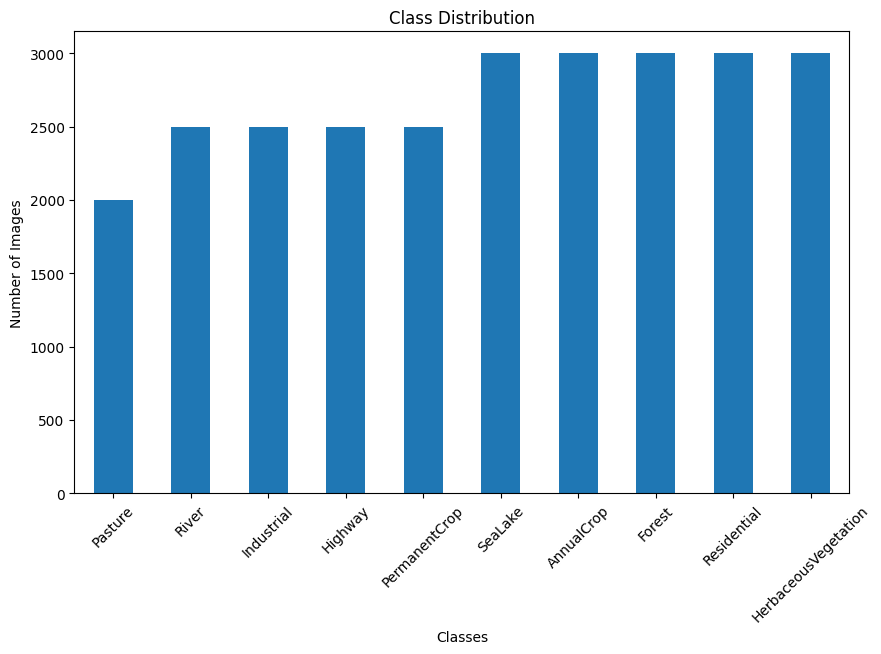

In [ ]:
class_distribution.sort_values(by = "Image Count").plot(kind = "bar", figsize = (10, 6), legend = False)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Classes")
plt.xticks(rotation = 45)
plt.show()

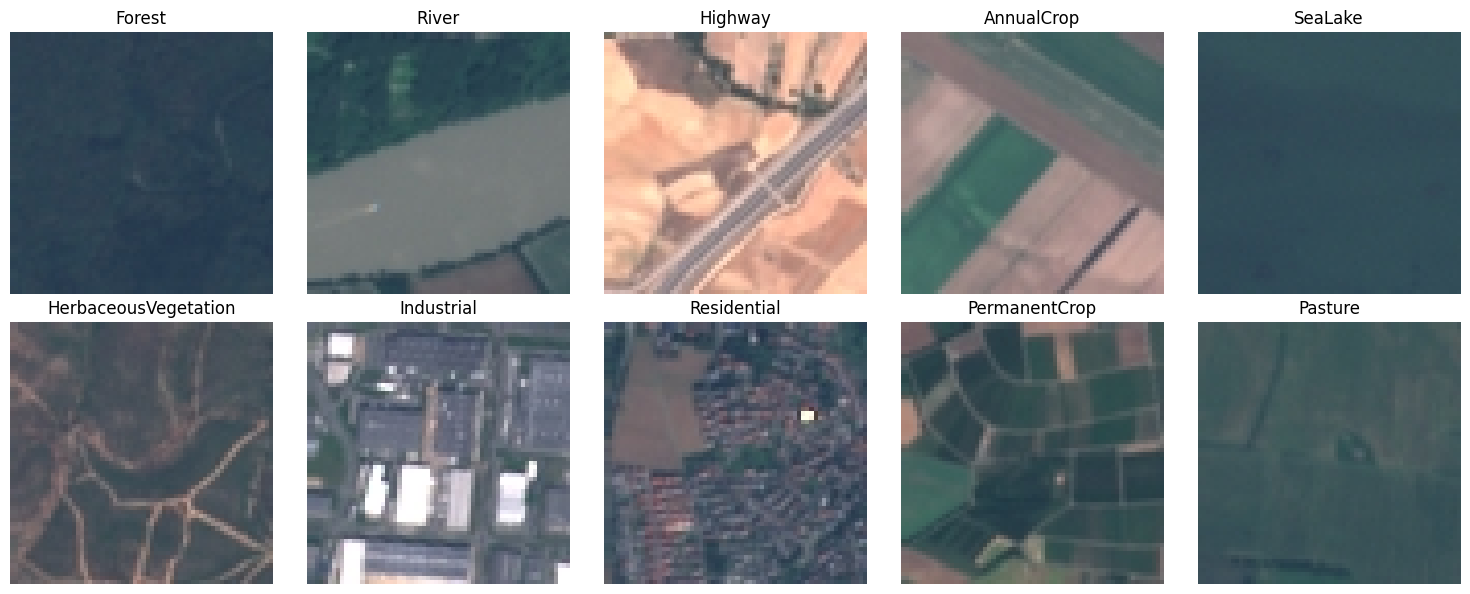

In [ ]:
fig, axes = plt.subplots(2, 5, figsize = (15, 6))
axes = axes.flatten()

for i, (class_name, _) in enumerate(class_counts.items()):
    class_dir = os.path.join(dataset_path, class_name)
    image_file = os.listdir(class_dir)[0]  # Select first image in the class directory
    image_path = os.path.join(class_dir, image_file)

    # Load and plot the image
    img = Image.open(image_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**<u>Notes:</u>**
- Each image has a size of $64 \times 64$.
- The following step takes around 10 minutes.

In [ ]:
# Initialize lists for storing flattened images and labels
images = []
labels = []

# Iterate through each class directory
for label, class_name in enumerate(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, class_name)
    for image_file in os.listdir(class_dir):
        # Load the image
        image_path = os.path.join(class_dir, image_file)
        img = Image.open(image_path).resize((64, 64))  # Resize to uniform size (64x64)
        img_array = np.array(img)  # Convert to NumPy array

        # Flatten the image (convert to 1D array)
        images.append(img_array.flatten())  # Shape: (H * W * C,)
        labels.append(label)  # Numeric label for the class

# Convert lists to NumPy arrays
X = np.array(images)  # Shape: (n_samples, n_pixels)
y = np.array(labels)  # Shape: (n_samples,)
print(f"Data shape: {X.shape}, Labels shape: {y.shape}")

Data shape: (27000, 12288), Labels shape: (27000,)


**<u>Data augmentation:</u>**
- To balance computational resources and efficiency, we only perform one single augmentation approach, namely, a random rotation up to 30 degrees.
- We also only generated one augmented image per original image, thus increasing the sample size from 27,000 to 54,000.
- The augmentation step takes around 12 minutes to complete.

In [ ]:
# Initialize ImageDataGenerator with rotation augmentation only
datagen = ImageDataGenerator(
    rotation_range = 30  # Random rotation up to 30 degrees
)

# Initialize lists for augmented images and labels
augmented_images = []
augmented_labels = []

# Apply rotation augmentation to each image in the dataset
for label, class_name in enumerate(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, class_name)
    for image_file in os.listdir(class_dir):
        # Load image and convert to NumPy array
        image_path = os.path.join(class_dir, image_file)
        img = Image.open(image_path).resize((64, 64))  # Resize to uniform size
        img_array = np.array(img).reshape((1,) + img.size + (3,))  # Reshape for ImageDataGenerator

        # Generate one augmented image per original image
        for batch in datagen.flow(img_array, batch_size=1):
            augmented_images.append(batch[0].flatten())  # Flatten augmented image
            augmented_labels.append(label)              # Append corresponding label
            break  # Generate only one augmented image per original image

# Convert augmented data to NumPy arrays
X_augmented = np.array(augmented_images)
y_augmented = np.array(augmented_labels)

print(f"Augmented data shape: {X_augmented.shape}, Augmented labels shape: {y_augmented.shape}")

Augmented data shape: (27000, 12288), Augmented labels shape: (27000,)


In [ ]:
# Combine original data (X, y) with augmented data (X_augmented, y_augmented)
X_combined = np.vstack((X, X_augmented))
y_combined = np.hstack((y, y_augmented))

print(f"Total dataset size after augmentation: {X_combined.shape}, Labels shape: {y_combined.shape}")

Total dataset size after augmentation: (54000, 12288), Labels shape: (54000,)


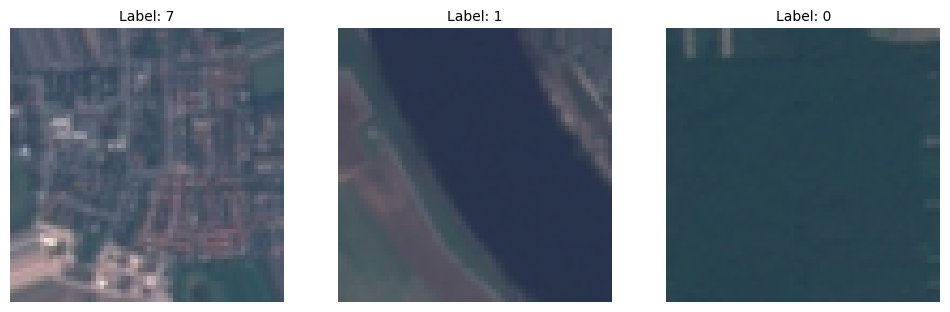

In [ ]:
# Select three random indices from the combined dataset
random.seed(42)
random_indices = random.sample(range(27001, 54000), 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, idx in enumerate(random_indices):
    img_array = X_combined[idx].reshape(64, 64, -1)  # Reshape back to original dimensions (64x64x3)
    axes[i].imshow(img_array.astype(np.uint8))       # Convert array to uint8 for visualization
    axes[i].axis("off")
    axes[i].set_title(f"Label: {y_combined[idx]}", fontsize = 10)
plt.show()

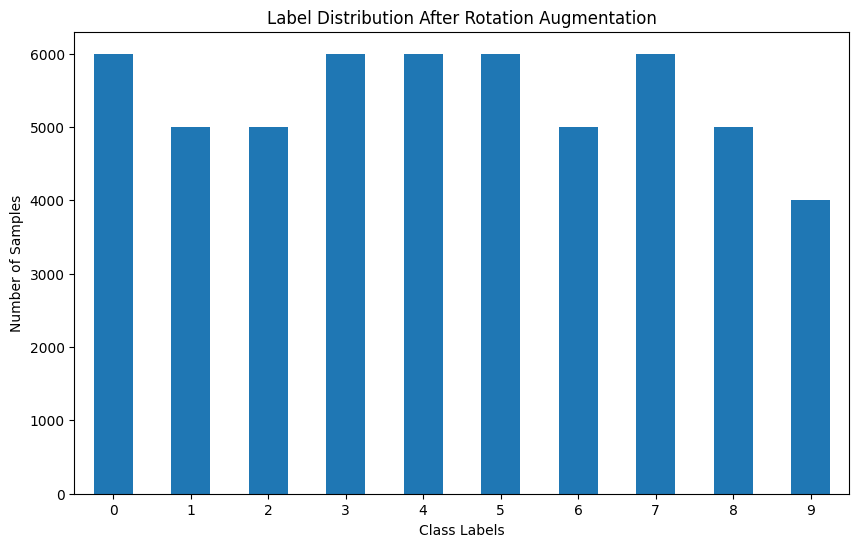

In [ ]:
# Count occurrences of each class label in the combined labels array
label_counts = pd.Series(y_combined).value_counts()

# Plot histogram of label distribution
label_counts.sort_index().plot(kind='bar', figsize=(10, 6))
plt.title("Label Distribution After Rotation Augmentation")
plt.xlabel("Class Labels")
plt.ylabel("Number of Samples")
plt.xticks(rotation = 0)
plt.show()

In [ ]:
# Save combined data and labels using Pickle
with open("/content/drive/MyDrive/MUSA-650/A4_dataset.pkl", "wb") as f:
    pickle.dump((X, y, X_augmented, y_augmented, X_combined, y_combined), f)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
# Load the saved data and labels using Pickle
with open("/content/drive/MyDrive/MUSA-650/A4_dataset.pkl", "rb") as f:
    X, y, X_augmented, y_augmented, X_combined, y_combined = pickle.load(f)

print(f"Loaded dataset shapes: {X.shape}, {y.shape}, {X_augmented.shape}, {y_augmented.shape}, {X_combined.shape}, {y_combined.shape}")

Loaded dataset shapes: (27000, 12288), (27000,), (27000, 12288), (27000,), (54000, 12288), (54000,)


In [ ]:
# Split combined data into training (60%) and testing (40%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined,
    test_size = 0.4,
    random_state = 42,
    stratify = y_combined  # Ensure class proportions are preserved
)

print(f"Training data shape: {X_train.shape}, Testing data shape: {X_test.shape}")

Training data shape: (32400, 12288), Testing data shape: (21600, 12288)


The grayscale conversion takes 3 seconds.

In [ ]:
# Function to convert RGB images to grayscale
def convert_to_grayscale(X, image_size = (64, 64)):
    grayscale_images = []
    for img_flat in X:
        # Reshape flattened image back to original dimensions
        img_array = img_flat.reshape(image_size[0], image_size[1], -1)
        # Convert to grayscale using Pillow
        img = Image.fromarray(img_array.astype(np.uint8))
        img_gray = img.convert("L")  # Convert to grayscale ('L' mode)
        # Flatten grayscale image back to 1D array
        grayscale_images.append(np.array(img_gray).flatten())
    return np.array(grayscale_images)

# Convert training and testing datasets to grayscale
X_train_gray = convert_to_grayscale(X_train)
X_test_gray = convert_to_grayscale(X_test)

print(f"Grayscale Training Data Shape: {X_train_gray.shape}")
print(f"Grayscale Testing Data Shape: {X_test_gray.shape}")

Grayscale Training Data Shape: (32400, 4096)
Grayscale Testing Data Shape: (21600, 4096)


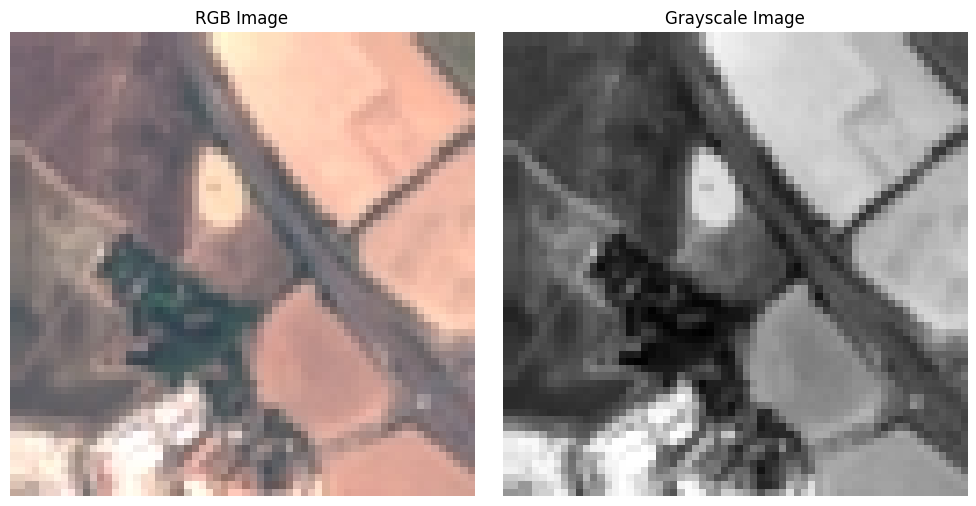

In [ ]:
# Define the image dimensions (e.g., 64x64)
image_size = (64, 64)

# Select an index to plot (e.g., the first image in the training set)
index = 10230

# Reshape the RGB image from X_train (flattened array) back to original dimensions
img_rgb = X_train[index].reshape(image_size[0], image_size[1], -1)  # Reshape to (64, 64, 3)

# Reshape the grayscale image from X_train_gray (flattened array) back to original dimensions
img_gray = X_train_gray[index].reshape(image_size[0], image_size[1])  # Reshape to (64, 64)

# Plot the images side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create a 1x2 grid of subplots

# Display the RGB image
axes[0].imshow(img_rgb.astype(np.uint8))  # Convert array to uint8 for visualization
axes[0].set_title("RGB Image")
axes[0].axis('off')  # Turn off axis for better visualization

# Display the grayscale image
axes[1].imshow(img_gray, cmap='gray')  # Use grayscale colormap
axes[1].set_title("Grayscale Image")
axes[1].axis('off')  # Turn off axis for better visualization

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()

## 2. Traditional Machine Learning

For this first section, we will only use the categories "Forest (F)", "Residential (R)" and "Industrial (I)". Make sure to subset the grayscale dataset, select only for these three classes.

### 2.1 Binary Support Vector Machine

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I] and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

In [ ]:
# Normalize grayscale images to [0, 1]
X_train_gray = X_train_gray / 255.0
X_test_gray = X_test_gray / 255.0

In [ ]:
# Filter the grayscale data based on the selected numeric categories
categories = [0, 7, 6]

# Create a mask for the categories in the training set
train_mask = np.isin(y_train, categories)

# Apply the mask to filter X_train and y_train
X_train_gray_filtered = X_train_gray[train_mask]
y_train_filtered = y_train[train_mask]

# Create a mask for the categories in the testing set
test_mask = np.isin(y_test, categories)

# Apply the mask to filter X_test and y_test
X_test_gray_filtered = X_test_gray[test_mask]
y_test_filtered = y_test[test_mask]

# Print the shapes of the filtered datasets
print(f"Filtered Training Data Shape: {X_train_gray_filtered.shape}")
print(f"Filtered Testing Data Shape: {X_test_gray_filtered.shape}")

Filtered Training Data Shape: (10200, 4096)
Filtered Testing Data Shape: (6800, 4096)


In [ ]:
# Function to create and train an SVM classifier for binary classification tasks
def train_svm_classifier(X_train, y_train, X_test, y_test, class_1, class_2):
    # Filter data for the current binary classification task
    mask_train = np.isin(y_train, [class_1, class_2])
    mask_test = np.isin(y_test, [class_1, class_2])

    X_train_filtered = X_train[mask_train]
    y_train_filtered = y_train[mask_train]
    X_test_filtered = X_test[mask_test]
    y_test_filtered = y_test[mask_test]

    # Relabel the classes to 0 and 1 for ROC
    y_train_binary = (y_train_filtered == class_2).astype(int)
    y_test_binary = (y_test_filtered == class_2).astype(int)

    # Train an SVM with a linear kernel
    model = SVC(kernel = "linear", probability = False)
    model.fit(X_train_filtered, y_train_binary)

    # Predict decision function scores
    y_scores = model.decision_function(X_test_filtered)

    # Predict class labels
    y_pred = model.predict(X_test_filtered)

    # Evaluate accuracy
    accuracy = accuracy_score(y_test_binary, y_pred)

    # Return model, accuracy, true labels, and decision scores
    return model, accuracy, y_test_binary, y_scores

# Train and evaluate the classifiers for each pair of categories

# 1. F vs R (0 vs 7)
model_FR, accuracy_FR, y_true_FR, y_score_FR = train_svm_classifier(X_train_gray_filtered, y_train_filtered, X_test_gray_filtered, y_test_filtered, 0, 7)
print(f"Accuracy for F vs R: {accuracy_FR * 100:.4f}%")

# 2. F vs I (0 vs 6)
model_FI, accuracy_FI, y_true_FI, y_score_FI = train_svm_classifier(X_train_gray_filtered, y_train_filtered, X_test_gray_filtered, y_test_filtered, 0, 6)
print(f"Accuracy for F vs I: {accuracy_FI * 100:.4f}%")

# 3. R vs I (7 vs 6)
model_RI, accuracy_RI, y_true_RI, y_score_RI = train_svm_classifier(X_train_gray_filtered, y_train_filtered, X_test_gray_filtered, y_test_filtered, 7, 6)
print(f"Accuracy for R vs I: {accuracy_RI * 100:.4f}%")

Accuracy for F vs R: 96.8958%
Accuracy for F vs I: 99.7727%
Accuracy for R vs I: 73.7045%


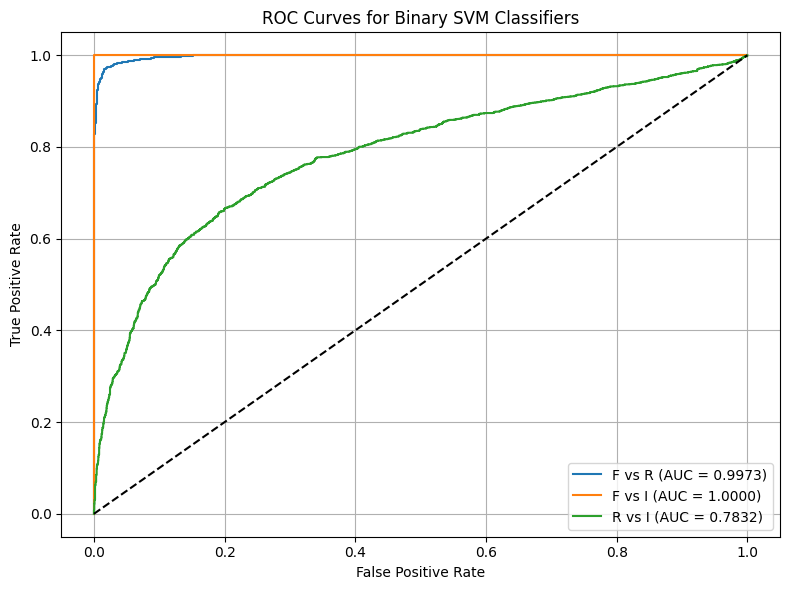

In [ ]:
# Compute ROC curves and AUCs
fpr_FR, tpr_FR, _ = roc_curve(y_true_FR, y_score_FR)
roc_auc_FR = auc(fpr_FR, tpr_FR)

fpr_FI, tpr_FI, _ = roc_curve(y_true_FI, y_score_FI)
roc_auc_FI = auc(fpr_FI, tpr_FI)

fpr_RI, tpr_RI, _ = roc_curve(y_true_RI, y_score_RI)
roc_auc_RI = auc(fpr_RI, tpr_RI)

# Plot the ROC curves
plt.figure(figsize = (8, 6))
plt.plot(fpr_FR, tpr_FR, label = f"F vs R (AUC = {roc_auc_FR:.4f})")
plt.plot(fpr_FI, tpr_FI, label = f"F vs I (AUC = {roc_auc_FI:.4f})")
plt.plot(fpr_RI, tpr_RI, label = f"R vs I (AUC = {roc_auc_RI:.4f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Binary SVM Classifiers")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

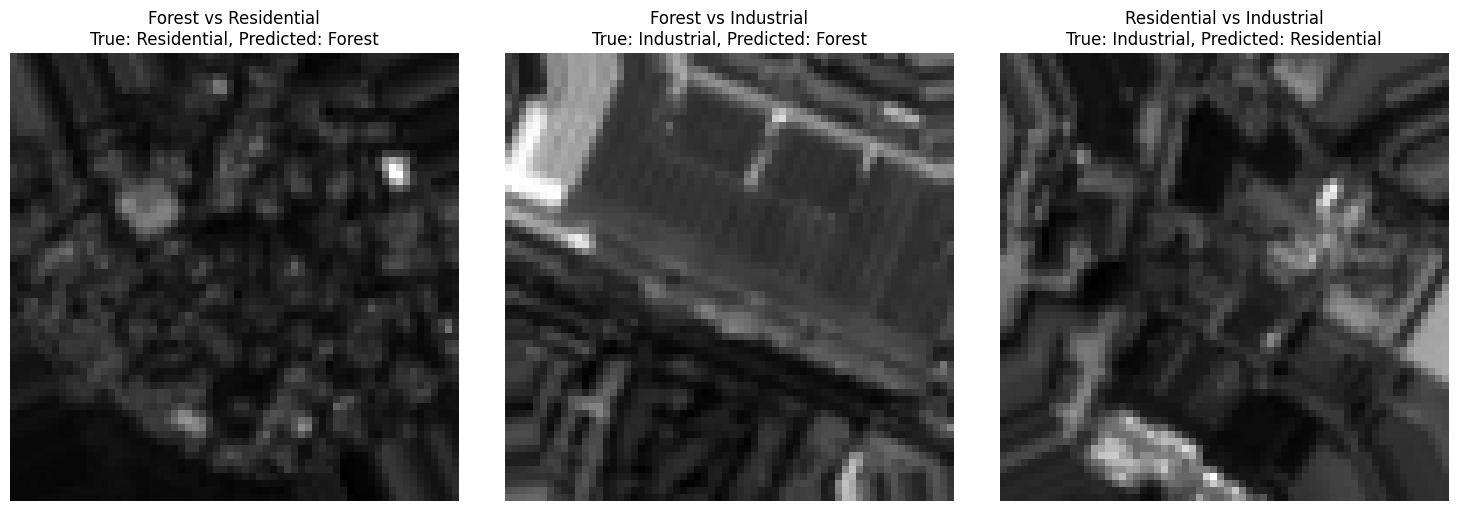

In [ ]:
# Dictionary for label mapping
# List of classifiers, class pairs, and titles
classifiers = [model_FR, model_FI, model_RI]
class_pairs = [(0, 7), (0, 6), (7, 6)]  # (class_1, class_2) pairs for each model
titles = ["Forest vs Residential", "Forest vs Industrial", "Residential vs Industrial"]
label_map = {0: "Forest", 7: "Residential", 6: "Industrial"}  # Label to class mapping

# Create a subplot grid for 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# Loop through each classifier and class pair
for i, (model, (class_1, class_2), title) in enumerate(zip(classifiers, class_pairs, titles)):
    # Filter data for the binary task
    mask = np.isin(y_test_filtered, [class_1, class_2])
    X_filtered = X_test_gray_filtered[mask]
    y_true = y_test_filtered[mask]

    # Relabel to 0 (class_1) and 1 (class_2)
    y_binary = (y_true == class_2).astype(int)

    # Predict using the model
    y_pred = model.predict(X_filtered)

    # Find misclassified indices
    misclassified = np.where(y_pred != y_binary)[0]

    if len(misclassified) > 0:
        # Get the first misclassified image
        idx = misclassified[0]
        img = X_filtered[idx].reshape(64, 64)  # Assuming the image is 64x64 pixels

        true_label = label_map[class_1] if y_binary[idx] == 0 else label_map[class_2]
        pred_label = label_map[class_1] if y_pred[idx] == 0 else label_map[class_2]

        # Plot the misclassified image in the corresponding subplot
        ax = axes[i]
        ax.imshow(img, cmap = "gray")
        ax.set_title(f"{title}\nTrue: {true_label}, Predicted: {pred_label}")
        ax.axis("off")
    else:
        print(f"No misclassifications found for {title}.")

# Show the images
plt.tight_layout()
plt.show()

### 2.2 Multiclass, Majority-Vote Support Vector Machine

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

In [ ]:
# Define Majority Voting Function
def predict_three_class_sample(x):
    votes = []

    # Forest vs Residential (0 vs 7)
    pred_FR = model_FR.predict(x.reshape(1, -1))[0]
    votes.append(0 if pred_FR == 0 else 7)

    # Forest vs Industrial (0 vs 6)
    pred_FI = model_FI.predict(x.reshape(1, -1))[0]
    votes.append(0 if pred_FI == 0 else 6)

    # Residential vs Industrial (7 vs 6)
    pred_RI = model_RI.predict(x.reshape(1, -1))[0]
    votes.append(7 if pred_RI == 0 else 6)

    # Majority vote
    final_pred = Counter(votes).most_common(1)[0][0]
    return final_pred

In [ ]:
#Filter the Test Set for Classes [0, 6, 7]
mask_three = np.isin(y_test_filtered, [0, 6, 7])
X_three = X_test_gray_filtered[mask_three]
y_three = y_test_filtered[mask_three]

# Predict on the 3-class test set using majority voting
y_pred_combined = np.array([predict_three_class_sample(x) for x in X_three])

# Accuracy
accuracy_combined = accuracy_score(y_three, y_pred_combined)
print(f"Three-Class Classifier Accuracy: {accuracy_combined * 100:.4f}%")

Three-Class Classifier Accuracy: 81.0882%


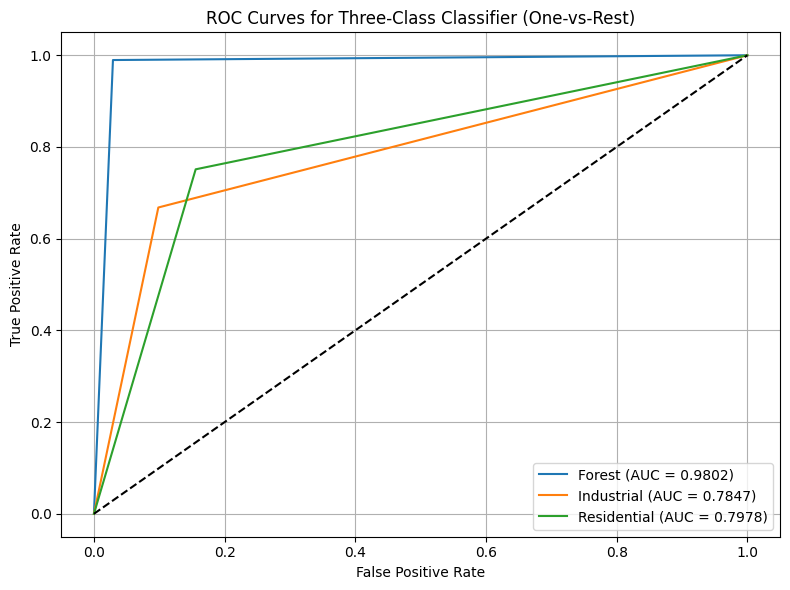

In [ ]:
# Binarize the y_true and y_pred arrays for ROC
classes = [0, 6, 7]  # Forest, Industrial, Residential
y_true_bin = label_binarize(y_three, classes = classes)
y_pred_bin = label_binarize(y_pred_combined, classes = classes)

#Compute ROC Curves and AUCs
fpr = {}
tpr = {}
roc_auc = {}

for i, class_id in enumerate(classes):
    fpr[class_id], tpr[class_id], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[class_id] = auc(fpr[class_id], tpr[class_id])

#Plot ROC Curves
plt.figure(figsize = (8, 6))
for class_id in classes:
    plt.plot(fpr[class_id], tpr[class_id], label = f"{label_map[class_id]} (AUC = {roc_auc[class_id]:.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Three-Class Classifier (One-vs-Rest)")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

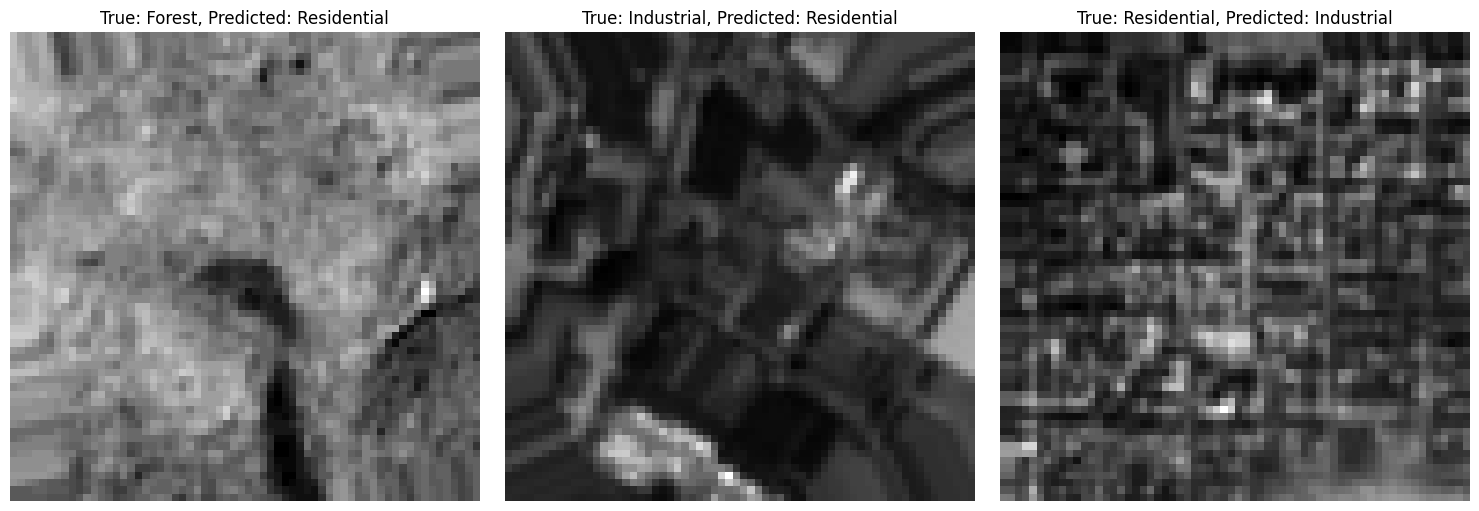

In [ ]:
# List of classes and the corresponding labels
classes = [0, 6, 7]  # Forest, Industrial, Residential
label_map = {0: "Forest", 7: "Residential", 6: "Industrial"}

# Create a subplot grid with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# Loop through each class to find a misclassified image
for i, class_id in enumerate(classes):
    # Find misclassified samples where the true label is `class_id` but predicted label is different
    mask = (y_three == class_id) & (y_pred_combined != class_id)
    misclassified_indices = np.where(mask)[0]

    if len(misclassified_indices) > 0:
        # Take the first misclassified index for each class
        idx = misclassified_indices[0]
        img = X_three[idx].reshape(64, 64)  # Reshape to 64x64 grayscale image

        # Get the true and predicted labels
        true_label = label_map[y_three[idx]]
        pred_label = label_map[y_pred_combined[idx]]

        # Display the image and labels in the corresponding subplot
        ax = axes[i]
        ax.imshow(img, cmap = "gray")
        ax.set_title(f"True: {true_label}, Predicted: {pred_label}")
        ax.axis("off")
    else:
        print(f"No misclassified images found for {label_map[class_id]}.")

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.

In [ ]:
# Filter training data for classes [0, 6, 7]
mask_train_three = np.isin(y_train_filtered, [0, 6, 7])
X_train_three = X_train_gray_filtered[mask_train_three]
y_train_three = y_train_filtered[mask_train_three]

# X_three and y_three already defined from earlier (test set)
# Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train_three, y_train_three)

# Predict on test data
y_pred_rf = rf_model.predict(X_three)

# Accuracy
accuracy_rf = accuracy_score(y_three, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.4f}%")

Random Forest Accuracy: 92.9265%


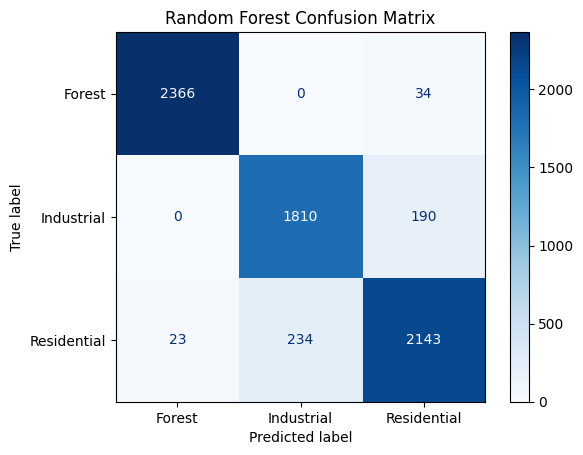

In [ ]:
# Plot confusion matrix
rf_conf = confusion_matrix(y_three, y_pred_rf, labels = [0, 6, 7])
disp = ConfusionMatrixDisplay(confusion_matrix = rf_conf, display_labels = ["Forest", "Industrial", "Residential"])
disp.plot(cmap = "Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

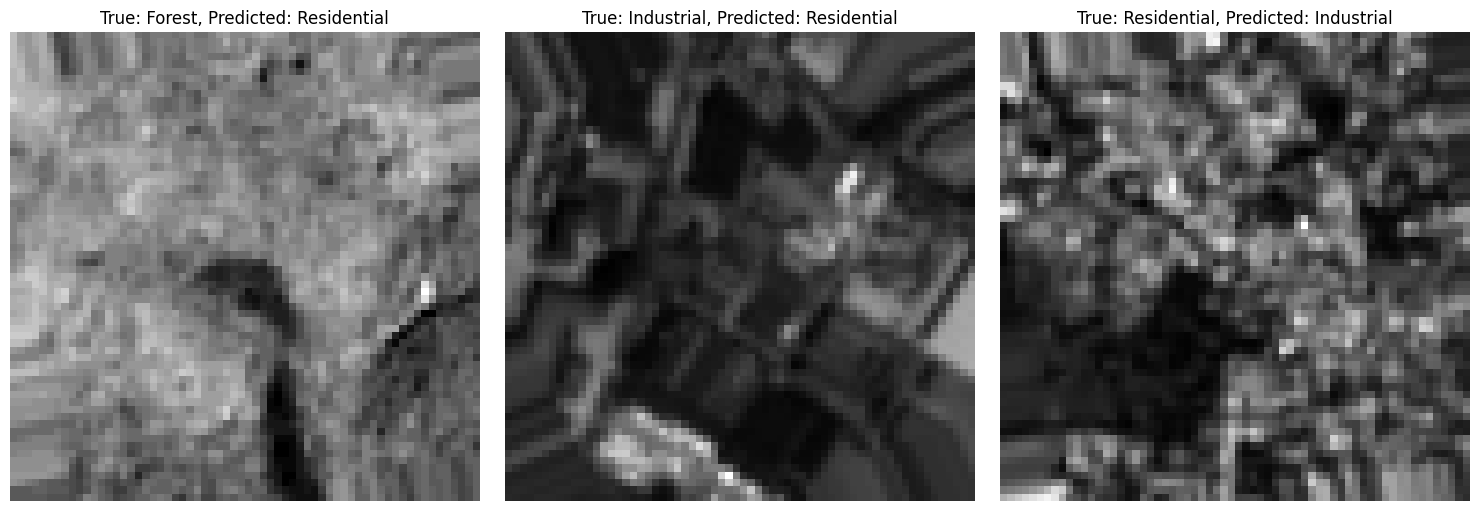

In [ ]:
# List of classes and the corresponding labels
classes = [0, 6, 7]  # Forest, Industrial, Residential
label_map = {0: "Forest", 7: "Residential", 6: "Industrial"}

# Create a subplot grid with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

# Loop through each class to find a misclassified image
for i, class_id in enumerate(classes):
    # Find misclassified samples where the true label is `class_id` but predicted label is different
    mask = (y_three == class_id) & (y_pred_rf != class_id)
    misclassified_indices = np.where(mask)[0]

    if len(misclassified_indices) > 0:
        # Take the first misclassified index for each class
        idx = misclassified_indices[0]
        img = X_three[idx].reshape(64, 64)  # Reshape to 64x64 grayscale image

        # Get the true and predicted labels
        true_label = label_map[y_three[idx]]
        pred_label = label_map[y_pred_rf[idx]]

        # Display the image and labels in the corresponding subplot
        ax = axes[i]
        ax.imshow(img, cmap = "gray")
        ax.set_title(f"True: {true_label}, Predicted: {pred_label}")
        ax.axis("off")
    else:
        print(f"No misclassified images found for {label_map[class_id]}.")

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

### 3.1 Greyscale Images

For this section, use the same greyscale images that you used in the traditional machine learning section.

#### 3.1.1 Model One

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e: input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

In [ ]:
# One-hot encode the labels
num_classes = len(np.unique(y_train))  # Number of land cover categories
y_train_categorical = to_categorical(y_train, num_classes = num_classes)
y_test_categorical = to_categorical(y_test, num_classes = num_classes)

print(f"X_train_gray shape: {X_train_gray.shape}, y_train_categorical shape: {y_train_categorical.shape}")
print(f"X_test_gray shape: {X_test_gray.shape}, y_test_categorical shape: {y_test_categorical.shape}")

X_train_gray shape: (32400, 4096), y_train_categorical shape: (32400, 10)
X_test_gray shape: (21600, 4096), y_test_categorical shape: (21600, 10)


In [ ]:
# Define the model
model_one = Sequential([
    # Flatten the input (grayscale image) from 1D array of pixels
    Flatten(input_shape = (X_train_gray.shape[1],)),  # Input layer
    Dense(num_classes, activation = "softmax")       # Fully connected output layer
])

# Compile the model
model_one.compile(optimizer = Adam(learning_rate = 0.001),
                  loss = "categorical_crossentropy",  # Loss function for multi-class classification
                  metrics = ["accuracy"])

# Print model summary (architecture)
model_one.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │          40,970 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

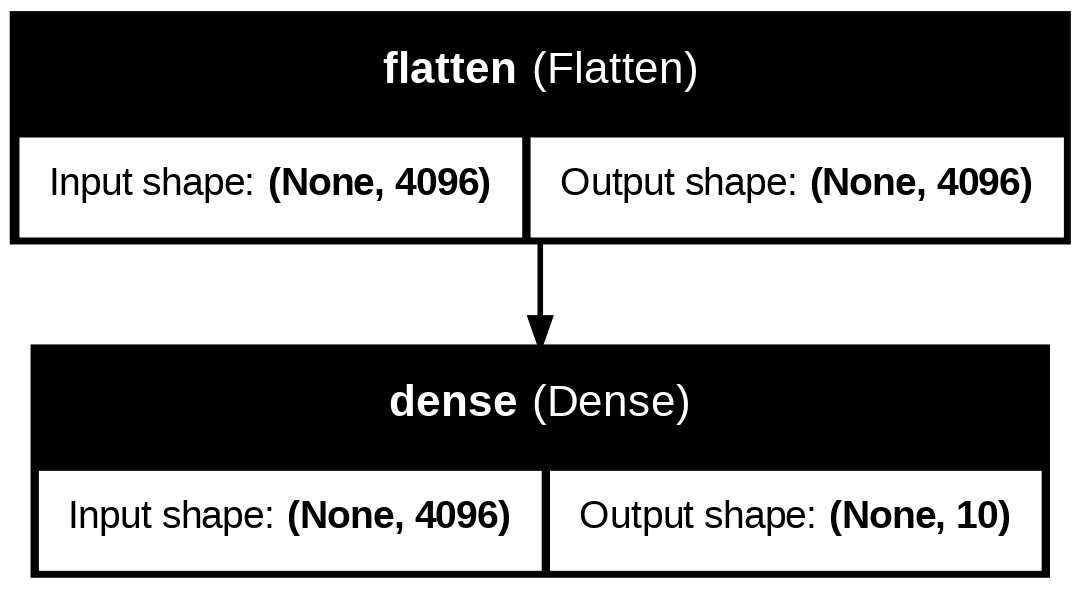

In [ ]:
# Visualize and save the model architecture as an image file
plot_model(model_one,
           to_file = "/content/drive/MyDrive/MUSA-650/model_one_architecture.png",
           show_shapes = True,
           show_layer_names = True)

In [ ]:
epochs = 10
batch_size = 32
model_one_history = model_one.fit(X_train_gray, y_train_categorical,
                        validation_data = (X_test_gray, y_test_categorical),
                        epochs = epochs,            # Number of training epochs
                        batch_size = batch_size,        # Batch size for training
                        verbose = 1)            # Print training progress

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1344 - loss: 2.3713 - val_accuracy: 0.2425 - val_loss: 2.3120
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1877 - loss: 2.2653 - val_accuracy: 0.2436 - val_loss: 2.2747
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2159 - loss: 2.2169 - val_accuracy: 0.2440 - val_loss: 2.2482
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2362 - loss: 2.1775 - val_accuracy: 0.2438 - val_loss: 2.2277
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2478 - loss: 2.1447 - val_accuracy: 0.2435 - val_loss: 2.2116
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2552 - loss: 2.1171 - val_accuracy: 0.2440 - val_loss: 2.1987
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2616 - loss: 2.0935 - val_accuracy: 0.2440 - val_loss: 2.1885
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2660 - loss: 2.0731 - 

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model_one.evaluate(X_test_gray, y_test_categorical, verbose = 0)

print(f"Test loss: {test_loss:.4f}.")
print(f"Test Accuracy: {test_accuracy * 100:.4f}%.")

Test loss: 2.1676.
Test Accuracy: 24.4676%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_one_history.json", "w") as f:
    json.dump(model_one_history.history, f)

model_one.save("/content/drive/MyDrive/MUSA-650/model_one.keras")

#### 3.1.2 Model Two

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

In [ ]:
# Define the second model with an additional hidden layer
model_two = Sequential([
    Flatten(input_shape = (X_train_gray.shape[1],)),  # Input layer (flattened grayscale image)
    Dense(128, activation = "relu"),                 # Hidden layer with 128 nodes and ReLU activation
    Dense(num_classes, activation = "softmax")       # Output layer with softmax activation
])

# Compile the model
model_two.compile(optimizer = "adam",               # Adam optimizer
                  loss = "categorical_crossentropy", # Loss function for multi-class classification
                  metrics = ["accuracy"])            # Track accuracy during training

# Print model summary (architecture)
model_two.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

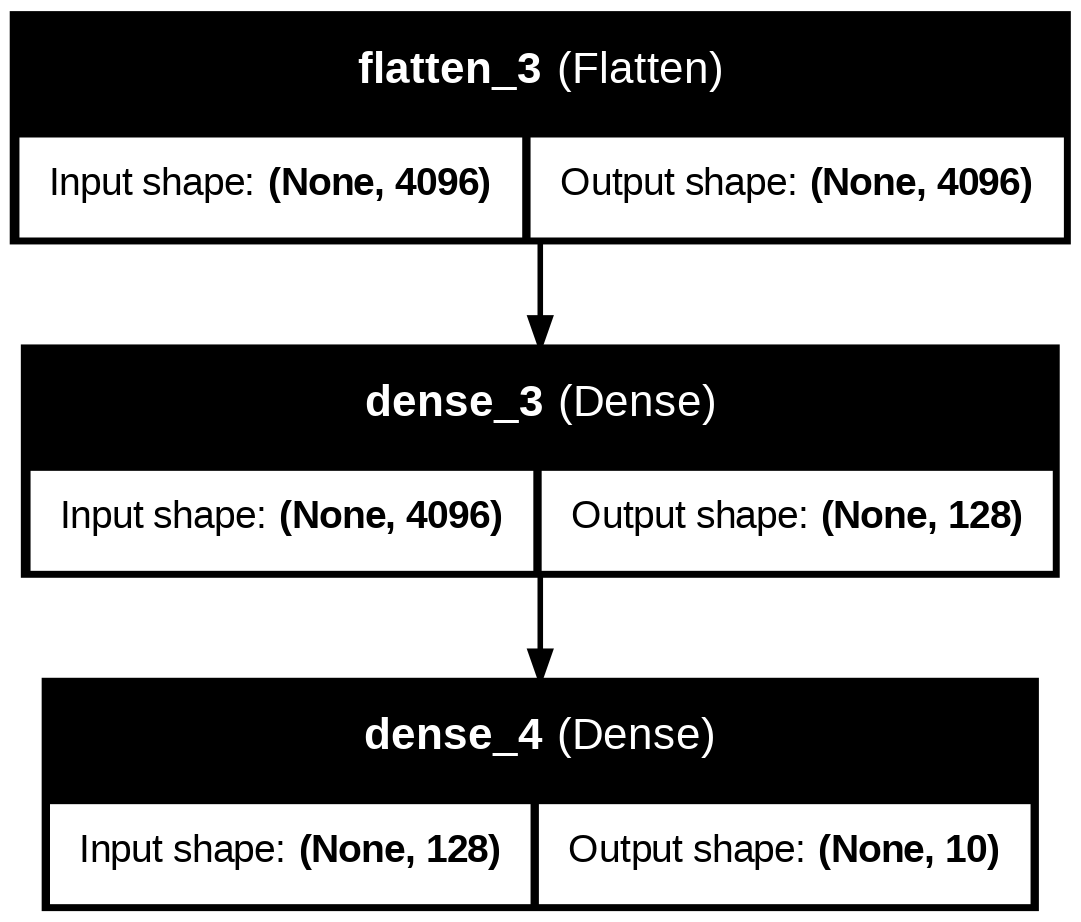

In [ ]:
# Visualize and save the model architecture as an image file
plot_model(model_two,
           to_file = "/content/drive/MyDrive/MUSA-650/model_two_architecture.png",
           show_shapes = True,
           show_layer_names = True)

In [ ]:
# Train the model
model_two_history = model_two.fit(X_train_gray, y_train_categorical,
                                  validation_data = (X_test_gray, y_test_categorical),
                                  epochs = epochs,
                                  batch_size = batch_size,
                                  verbose = 1)

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.1394 - loss: 2.2847 - val_accuracy: 0.1934 - val_loss: 2.1471
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2204 - loss: 2.1284 - val_accuracy: 0.2217 - val_loss: 2.0765
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2600 - loss: 2.0640 - val_accuracy: 0.2638 - val_loss: 2.0148
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2768 - loss: 2.0053 - val_accuracy: 0.2828 - val_loss: 1.9647
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2789 - loss: 1.9587 - val_accuracy: 0.2992 - val_loss: 1.9126
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2837 - loss: 1.9213 - val_accuracy: 0.2933 - val_loss: 1.8752
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2937 - loss: 1.8883 - val_accuracy: 0.2989 - val_loss: 1.8523
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.2956 - loss

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model_two.evaluate(X_test_gray, y_test_categorical, verbose = 0)

print(f"Test loss: {test_loss:.4f}.")
print(f"Test Accuracy: {test_accuracy * 100:.4f}%.")

Test loss: 1.8257.
Test Accuracy: 30.0741%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_two_history.json", "w") as f:
    json.dump(model_two_history.history, f)

model_two.save("/content/drive/MyDrive/MUSA-650/model_two.keras")

Test loss: 2.1676.
Test Accuracy: 24.4676%.
The additional hidden layer reduces the test loss by $2.1676 - 1.8257 = 0.3419$ and increases accuracy from 24.4676% to 30.0741% (a 5.6065 percentage point increase).
In short, we observe a moderate improvement in terms of model performance after we add an additional hidden layer.

The additional hidden layer allows the model to learn hierarchical features and captures more complex patterns in data.
Also, the hidden layer is activated by a ReLU function, which enables the model to learn non-linear relationship.
Hence, the additional hidden layer has the potential to improve accuracy.

At the same time, if we incorporate too many neurons to the hidden layer while the data is small or lack variability, it may lead to overfitting, hence potentially worsening accuracy.

#### 3.1.3 Model Three

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model’s performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

In [ ]:
# Define the third model with additional hidden layers and dropout
model_three = Sequential([
    Flatten(input_shape=(X_train_gray.shape[1],)),  # Input layer (flattened grayscale image)
    Dense(128, activation = "relu"),                 # First hidden layer with 128 nodes
    Dropout(0.1),                                  # Dropout layer (10% dropout)
    Dense(64, activation = "relu"),                  # Second hidden layer with 64 nodes
    Dropout(0.2),                                  # Dropout layer (20% dropout)
    Dense(32, activation = "relu"),                  # Third hidden layer with 32 nodes
    Dropout(0.3),                                  # Dropout layer (30% dropout)
    Dense(num_classes, activation = "softmax")       # Output layer with softmax activation
])

# Compile the model
model_three.compile(optimizer = "adam",               # Adam optimizer
                    loss = "categorical_crossentropy", # Loss function for multi-class classification
                    metrics = ["accuracy"])            # Track accuracy during training

# Print model summary (architecture)
model_three.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 535,082 (2.04 MB)

 Trainable params: 535,082 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

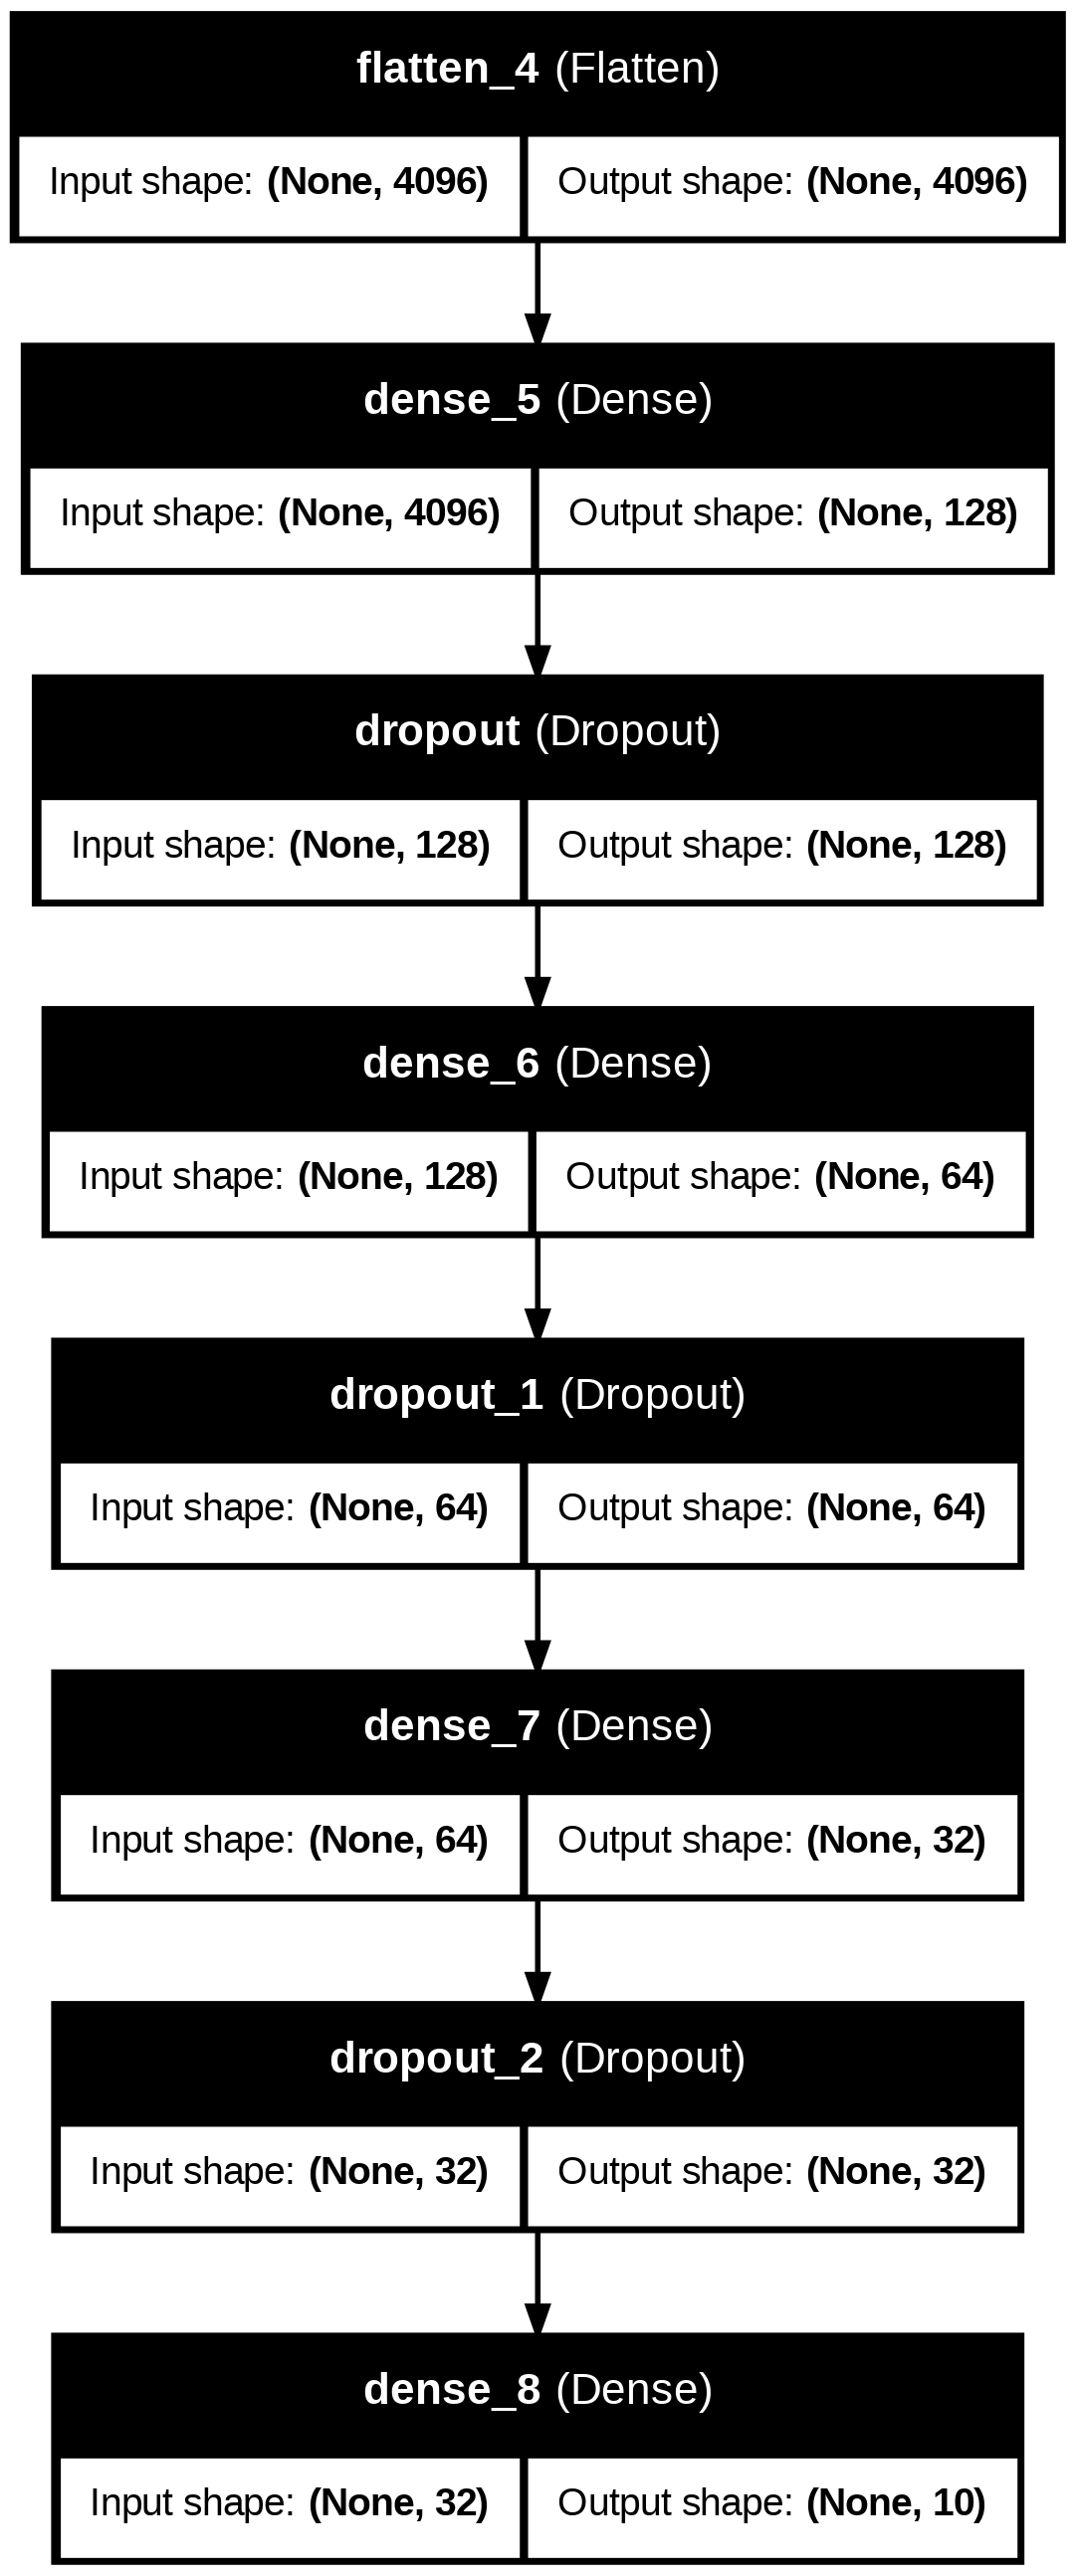

In [ ]:
# Visualize and save the model architecture as an image file
plot_model(model_three,
           to_file = "/content/drive/MyDrive/MUSA-650/model_three_architecture.png",
           show_shapes = True,
           show_layer_names = True)

In [ ]:
# Train the model
model_three_history = model_three.fit(X_train_gray, y_train_categorical,
                                      validation_data = (X_test_gray, y_test_categorical),
                                      epochs = epochs,
                                      batch_size = batch_size,
                                      verbose = 1)

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.1364 - loss: 2.2792 - val_accuracy: 0.2835 - val_loss: 1.9652
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2412 - loss: 1.9953 - val_accuracy: 0.2630 - val_loss: 1.8770
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.2677 - loss: 1.9028 - val_accuracy: 0.2835 - val_loss: 1.8287
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2822 - loss: 1.8680 - val_accuracy: 0.2922 - val_loss: 1.8093
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2954 - loss: 1.8440 - val_accuracy: 0.3025 - val_loss: 1.7554
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3060 - loss: 1.8365 - val_accuracy: 0.3237 - val_loss: 1.7755
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.3085 - loss: 1.8224 - val_accuracy: 0.3116 - val_loss: 1.7880
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2985 - l

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model_three.evaluate(X_test_gray, y_test_categorical, verbose = 0)

print(f"Test loss: {test_loss:.4f}.")
print(f"Test Accuracy: {test_accuracy * 100:.4f}%.")

Test loss: 1.8022.
Test Accuracy: 29.9259%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_three_history.json", "w") as f:
    json.dump(model_three_history.history, f)

model_three.save("/content/drive/MyDrive/MUSA-650/model_three.keras")

The dropout layers lower the model performance.
Model 3 has a slightly lower accuracy (29.9259%) than Model 2 (30.0741%), but a slightly lower loss (1.8022) than Model 2 (1.8257).

Dropout helps by regularizing the network through deactivating randomly a proportion of neurons, thus prevent overfitting.

Dropout might be more effective when we have limited sample size or over-parametrized networks, but it might be less effective if the dropout rates are improper selected or tuned.

#### 3.1.4 Model Comparison

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

In [ ]:
# Define the model
model_one_new = Sequential([
    # Flatten the input (grayscale image) from 1D array of pixels
    Flatten(input_shape = (X_train_gray.shape[1],)),  # Input layer
    Dense(num_classes, activation = "softmax")       # Fully connected output layer
])

# Compile the model
model_one_new.compile(optimizer = Adam(learning_rate = 0.001),
                  loss = "categorical_crossentropy",  # Loss function for multi-class classification
                  metrics = ["accuracy"])

# Print model summary (architecture)
model_one_new.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │          40,970 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs_new = 20
model_one_new_history = model_one_new.fit(X_train_gray, y_train_categorical,
                        validation_data = (X_test_gray, y_test_categorical),
                        epochs = epochs_new,            # Number of training epochs
                        batch_size = batch_size,        # Batch size for training
                        verbose = 1)            # Print training progress

Epoch 1/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1351 - loss: 2.3734 - val_accuracy: 0.2389 - val_loss: 2.3161
Epoch 2/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1890 - loss: 2.2649 - val_accuracy: 0.2420 - val_loss: 2.2772
Epoch 3/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2174 - loss: 2.2166 - val_accuracy: 0.2432 - val_loss: 2.2507
Epoch 4/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2373 - loss: 2.1773 - val_accuracy: 0.2436 - val_loss: 2.2306
Epoch 5/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2476 - loss: 2.1446 - val_accuracy: 0.2447 - val_loss: 2.2148
Epoch 6/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2546 - loss: 2.1170 - val_accuracy: 0.2445 - val_loss: 2.2023
Epoch 7/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2607 - loss: 2.0933 - val_accuracy: 0.2440 - val_loss: 2.1922
Epoch 8/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.2648 - loss: 2.0730 - 

In [ ]:
# Evaluate the model on test data
model_one_test_loss_new, model_one_test_accuracy_new = model_one_new.evaluate(X_test_gray, y_test_categorical, verbose = 0)

print(f"Test loss: {model_one_test_loss_new:.4f}.")
print(f"Test Accuracy: {model_one_test_accuracy_new * 100:.4f}%.")

Test loss: 2.1356.
Test Accuracy: 25.3519%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_one_new_history.json", "w") as f:
    json.dump(model_one_new_history.history, f)

model_one_new.save("/content/drive/MyDrive/MUSA-650/model_one_new.keras")

In [ ]:
# Define the second model with an additional hidden layer
model_two_new = Sequential([
    Flatten(input_shape = (X_train_gray.shape[1],)),  # Input layer (flattened grayscale image)
    Dense(128, activation = "relu"),                 # Hidden layer with 128 nodes and ReLU activation
    Dense(num_classes, activation = "softmax")       # Output layer with softmax activation
])

# Compile the model
model_two_new.compile(optimizer = "adam",               # Adam optimizer
                  loss = "categorical_crossentropy", # Loss function for multi-class classification
                  metrics = ["accuracy"])            # Track accuracy during training

# Print model summary (architecture)
model_two_new.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
model_two_new_history = model_two_new.fit(X_train_gray, y_train_categorical,
                                  validation_data = (X_test_gray, y_test_categorical),
                                  epochs = epochs_new,
                                  batch_size = batch_size,
                                  verbose = 1)

Epoch 1/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.1357 - loss: 2.2971 - val_accuracy: 0.1918 - val_loss: 2.1305
Epoch 2/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.2179 - loss: 2.1151 - val_accuracy: 0.2020 - val_loss: 2.0584
Epoch 3/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.2551 - loss: 2.0399 - val_accuracy: 0.2566 - val_loss: 1.9900
Epoch 4/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.2840 - loss: 1.9673 - val_accuracy: 0.2866 - val_loss: 1.9176
Epoch 5/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.2982 - loss: 1.8998 - val_accuracy: 0.2926 - val_loss: 1.8719
Epoch 6/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2996 - loss: 1.8546 - val_accuracy: 0.3000 - val_loss: 1.8377
Epoch 7/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3031 - loss: 1.8242 - val_accuracy: 0.2988 - val_loss: 1.8261
Epoch 8/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.3070 - lo

In [ ]:
# Evaluate the model on test data
model_two_test_loss_new, model_two_test_accuracy_new = model_two_new.evaluate(X_test_gray, y_test_categorical, verbose = 0)

print(f"Test loss: {model_two_test_loss_new:.4f}.")
print(f"Test Accuracy: {model_two_test_accuracy_new * 100:.4f}%.")

Test loss: 1.7793.
Test Accuracy: 30.1620%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_two_new_history.json", "w") as f:
    json.dump(model_two_new_history.history, f)

model_two_new.save("/content/drive/MyDrive/MUSA-650/model_two_new.keras")

In [ ]:
# Define the third model with additional hidden layers and dropout
model_three_new = Sequential([
    Flatten(input_shape=(X_train_gray.shape[1],)),  # Input layer (flattened grayscale image)
    Dense(128, activation = "relu"),                 # First hidden layer with 128 nodes
    Dropout(0.1),                                  # Dropout layer (10% dropout)
    Dense(64, activation = "relu"),                  # Second hidden layer with 64 nodes
    Dropout(0.2),                                  # Dropout layer (20% dropout)
    Dense(32, activation = "relu"),                  # Third hidden layer with 32 nodes
    Dropout(0.3),                                  # Dropout layer (30% dropout)
    Dense(num_classes, activation = "softmax")       # Output layer with softmax activation
])

# Compile the model
model_three_new.compile(optimizer = "adam",               # Adam optimizer
                    loss = "categorical_crossentropy", # Loss function for multi-class classification
                    metrics = ["accuracy"])            # Track accuracy during training

# Print model summary (architecture)
model_three_new.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 535,082 (2.04 MB)

 Trainable params: 535,082 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
model_three_new_history = model_three_new.fit(X_train_gray, y_train_categorical,
                                      validation_data = (X_test_gray, y_test_categorical),
                                      epochs = epochs_new,
                                      batch_size = batch_size,
                                      verbose = 1)

Epoch 1/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1435 - loss: 2.2686 - val_accuracy: 0.2831 - val_loss: 1.9038
Epoch 2/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.2548 - loss: 1.9568 - val_accuracy: 0.2914 - val_loss: 1.8331
Epoch 3/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2749 - loss: 1.8893 - val_accuracy: 0.3105 - val_loss: 1.7784
Epoch 4/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2903 - loss: 1.8531 - val_accuracy: 0.2974 - val_loss: 1.8052
Epoch 5/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3047 - loss: 1.8278 - val_accuracy: 0.3555 - val_loss: 1.7101
Epoch 6/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.3065 - loss: 1.8254 - val_accuracy: 0.3297 - val_loss: 1.7796
Epoch 7/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.3100 - loss: 1.8116 - val_accuracy: 0.3040 - val_loss: 1.8203
Epoch 8/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.3148 -

In [ ]:
# Evaluate the model on test data
model_three_test_loss_new, model_three_test_accuracy_new = model_three_new.evaluate(X_test_gray, y_test_categorical, verbose = 0)

print(f"Test loss: {model_three_test_loss_new:.4f}.")
print(f"Test Accuracy: {model_three_test_accuracy_new * 100:.4f}%.")

Test loss: 1.7063.
Test Accuracy: 34.0648%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_three_new_history.json", "w") as f:
    json.dump(model_three_new_history.history, f)

model_three_new.save("/content/drive/MyDrive/MUSA-650/model_three_new.keras")

Number of parameters:
- Model 1: 40,970
- Model 2: 525,706
- Model 3: 535,082

Model 3 has the most parameters to learn, more than 13 times the number of parameters Model 1 has ($535,082 \div 40,970 \approx 13.06$) and slightly more than the number of parameters Model 2 has ($535,082 - 525,706 = 9,376$).

Test loss and accuracy:
- Model 1: Loss $\approx 2.1676$; Accuracy $\approx 24.4676\%$.
- Model 2: Loss $\approx 1.8257$; Accuracy $\approx 30.0741\%$.
- Model 3: Loss $\approx 1.8022$; Accuracy $\approx 29.9259\%$.

In terms of test accuracy, Model 2 is the best, achieving the highest test accuracy among the 3 models.
When it comes to test loss though, Model 3 has an edge over Model 2, achieving the lowest test loss among the 3 models, although the difference is not substantive.
Overall, Model 2 would be the model I prefer, owing to the highest test accuracy it achieves.

Reasons why Model 2 performs the best:
- Model 2 incorporates one hidden layer with 128 neurons, which allows it to learn meaningful patterns from the data while not over-complicating the model architecture.
- Model 1 has no hidden layer, so its ability to learn complex patterns is limited.
- Model 3 has multiple hidden layers, which constitutes to a complex model architecture.
That being said, its test accuracy is slightly worse than Model 2.

Impact of increasing the number of training epochs: After doubling the number of epochs from 10 to 20, we have the following observations.
- Model 1: It has a slightly higher accuracy and slightly lower loss.
- Model 2: The model performs slightly better in both test loss and accuracy.
- Model 3: Similar to Model 2, the model performs slightly better in both test loss and accuracy.
In addition, Model 3 now is the best model after increasing the number of epochs from 10 to 20, in terms of both test accuracy and loss.

**Bonus:** Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual model? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

**<u>Remark:</u>** For this bonus part, I use the new models (trained with 20 epochs) since these models are in general more accurate.

The ensemble approach I implemented is averaging.
- **<u>Step 1:</u>**
Obtain the prediction probabilities for each of `model_one_new`, `model_two_new`, and `model_three_new`.
- **<u>Step 2:</u>**
Calculate the average predicted probabilities of the three models.
- **<u>Step 3:</u>**
Obtain the ensembled prediction by selecting the label with the highest average predicted probability.

In [ ]:
# Generate predictions for each model
predictions_one = model_one_new.predict(X_test_gray)  # Probabilities from Model One
predictions_two = model_two_new.predict(X_test_gray)  # Probabilities from Model Two
predictions_three = model_three_new.predict(X_test_gray)  # Probabilities from Model Three

# Average probabilities across models
average_probabilities = (predictions_one + predictions_two + predictions_three) / 3

# Convert averaged probabilities to class labels (argmax)
final_predictions = average_probabilities.argmax(axis = 1)

675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Calculate ensemble accuracy
ensemble_accuracy = accuracy_score(y_test, final_predictions)

print(f"Ensemble Model Accuracy: {ensemble_accuracy * 100:.4f}%.")

Ensemble Model Accuracy: 31.6667%.


The ensemble model achieves a test accuracy of 31.6667%.
This test accuracy is higher than that of Models 1 and 2, but lower than that of Model 3.

Potential improvement from ensembling:
- Ensembling combines the strengths of various models, while mitigating weaknesses of individual models by compensating with other included models.
- Ensembling can reduce variance by averaging out errors across models, leading more stable and robust predictions.
Also, aggregating predictions can help lessen the sensitivity of the data to noise and reduce the risk of overfitting.

Hence, ensembling could improve model accuracy compared to the individual models.

### 3.2 RGB Images

For this section, use the original RGB images.

#### 3.2.1 Model Four

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

In [ ]:
# Define Model Four (CNN)
model_four = Sequential([
    Conv2D(16, kernel_size = (3, 3),
           activation = "relu",
           input_shape = (64, 64, 3)),
    Conv2D(32, kernel_size = (3, 3),
           activation = "relu"),
    MaxPooling2D(pool_size = (2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(64, activation = "relu"),
    Dropout(0.5),
    Dense(num_classes, activation = "softmax")
])

# Compile the model
model_four.compile(optimizer = "adam",
                   loss = "categorical_crossentropy",
                   metrics = ["accuracy"])

# Print model summary
model_four.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 60, 60, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 28800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │       1,843,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,849,002 (7.05 MB)

 Trainable params: 1,849,002 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

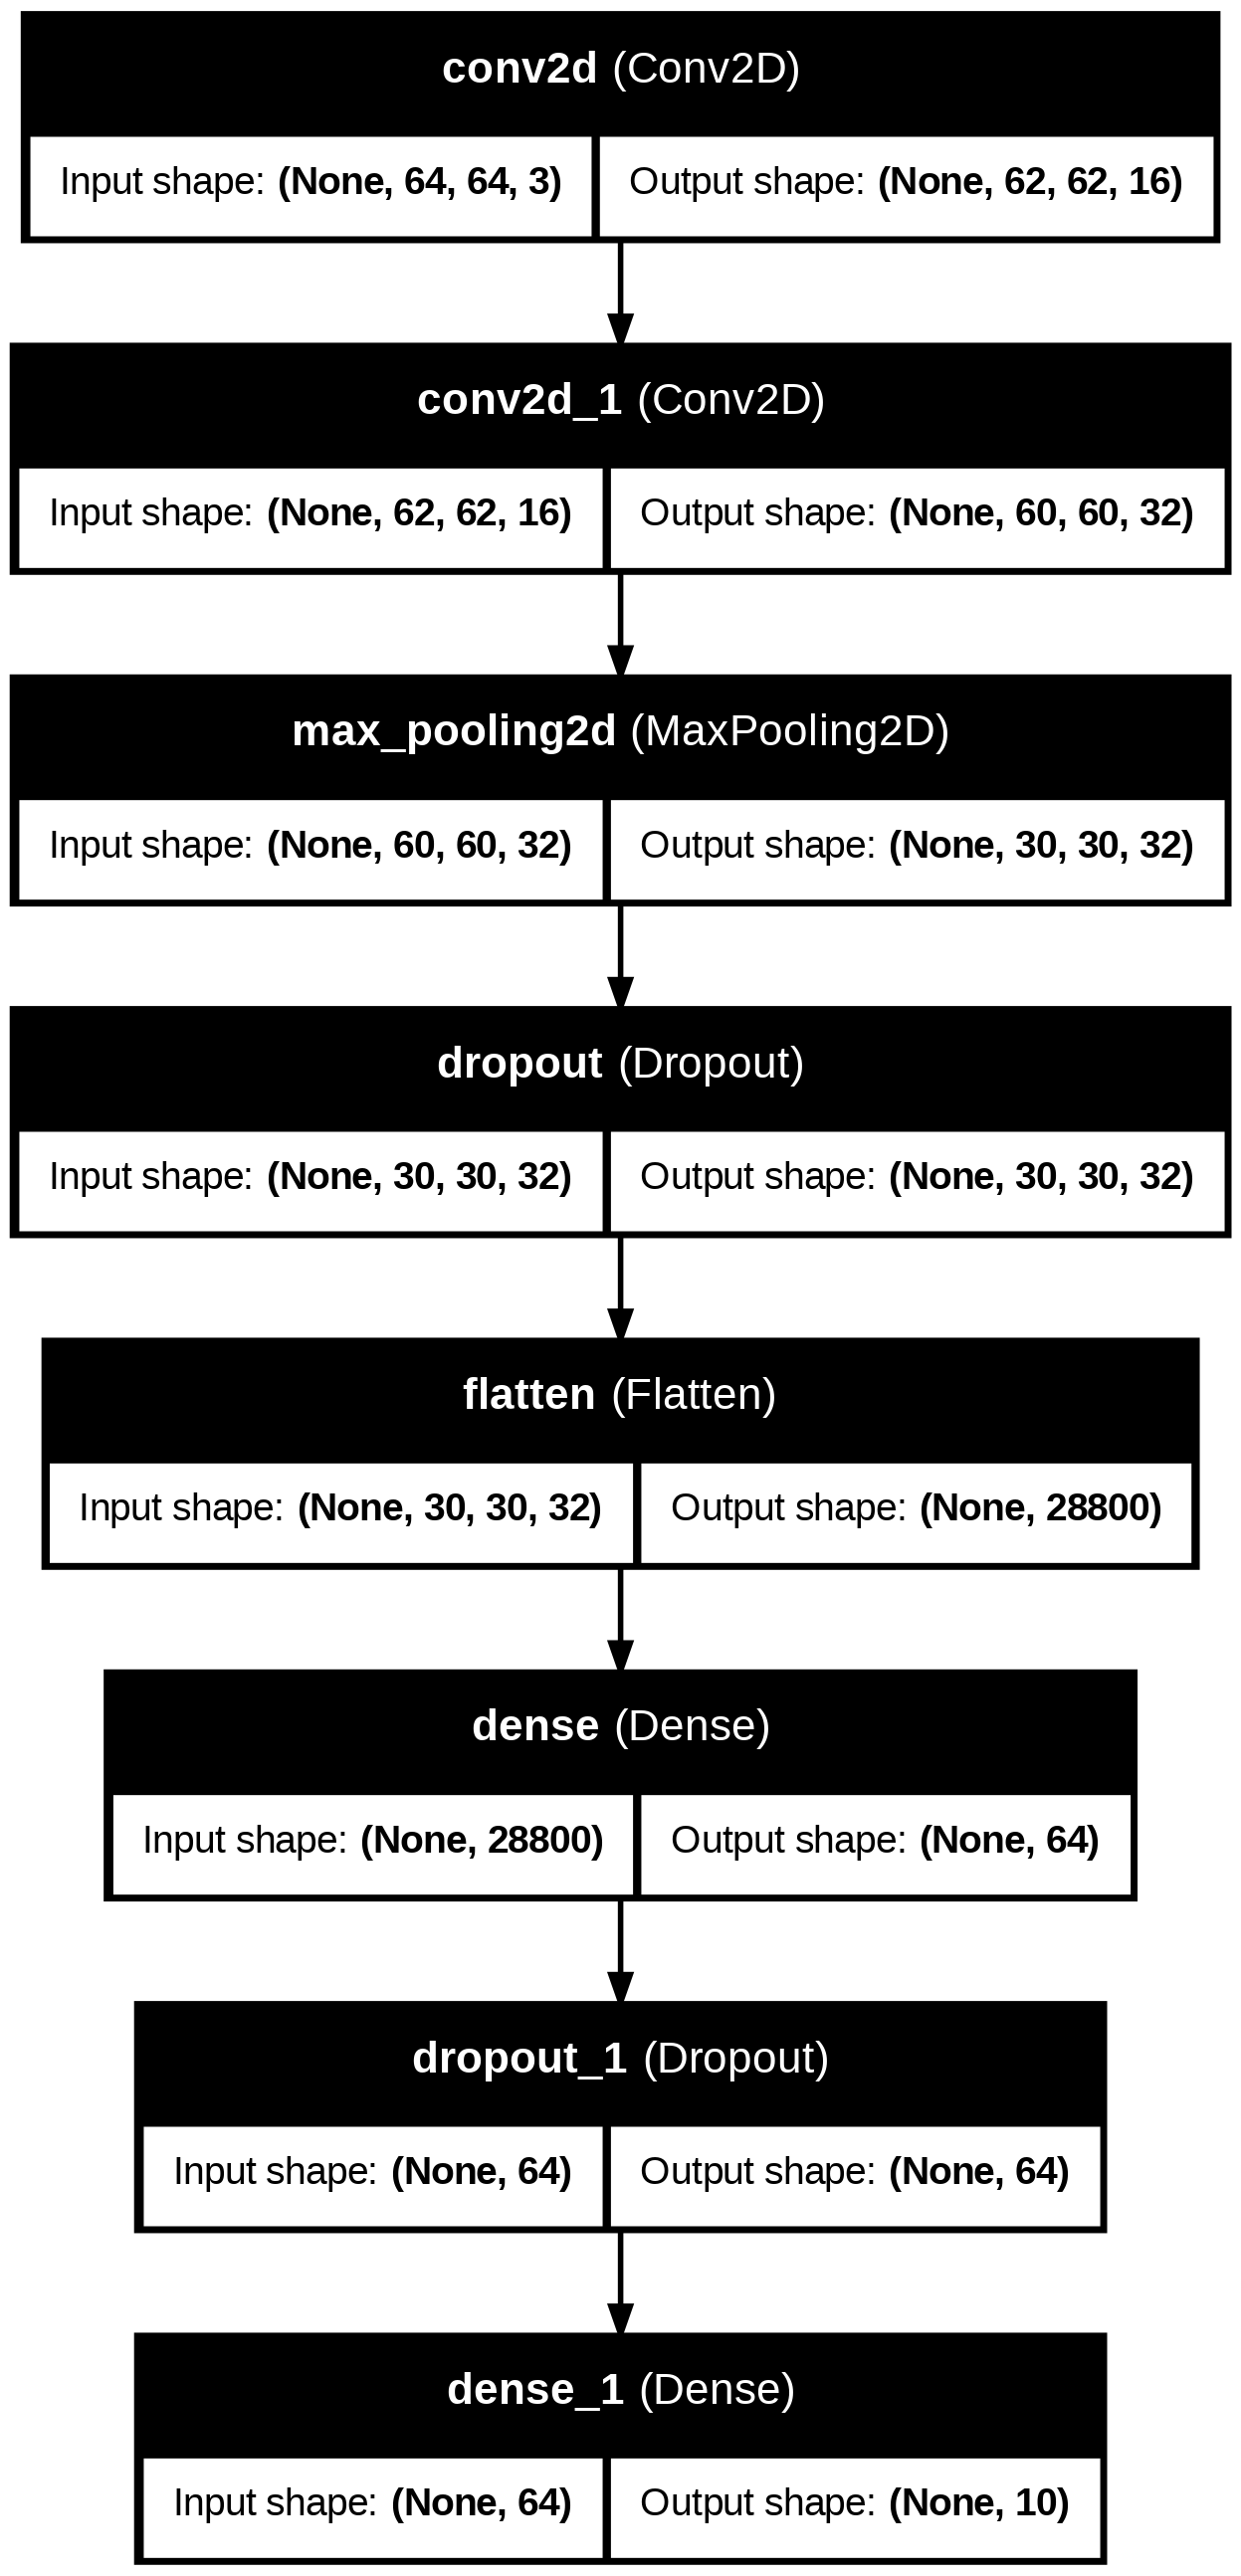

In [ ]:
# Save and visualize the model architecture
plot_model(model_four,
           to_file = "/content/drive/MyDrive/MUSA-650/model_four_architecture.png",
           show_shapes = True,
           show_layer_names = True)

In [ ]:
if K.image_data_format() == "channels_first":
    X_train = X_train.reshape(X_train.shape[0], 3, 64, 64)
    X_test = X_test.reshape(X_test.shape[0], 3, 64, 64)
    input_shape = (3, 64, 64)
else:
    X_train = X_train.reshape(X_train.shape[0], 64, 64, 3)
    X_test = X_test.reshape(X_test.shape[0], 64, 64, 3)
    input_shape = (64, 64, 3)

# Normalize pixel values after reshaping
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
epochs = 10
batch_size = 32

In [ ]:
# Train Model Four
model_four_history = model_four.fit(X_train, y_train_categorical,
                                    validation_data = (X_test, y_test_categorical),
                                    epochs = epochs,
                                    batch_size = batch_size,
                                    verbose = 1)

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4052 - loss: 1.6053 - val_accuracy: 0.6523 - val_loss: 0.9558
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6287 - loss: 1.0407 - val_accuracy: 0.7325 - val_loss: 0.7702
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6911 - loss: 0.8754 - val_accuracy: 0.7403 - val_loss: 0.7450
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7248 - loss: 0.7821 - val_accuracy: 0.7838 - val_loss: 0.6047
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7456 - loss: 0.7197 - val_accuracy: 0.7569 - val_loss: 0.6740
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7641 - loss: 0.6663 - val_accuracy: 0.7825 - val_loss: 0.6317
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7746 - loss: 0.6251 - val_accuracy: 0.8010 - val_loss: 0.5691
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7795 - loss: 0.608

In [ ]:
# Evaluate Model Four on test data
model_four_test_loss, model_four_test_accuracy = model_four.evaluate(X_test, y_test_categorical, verbose = 0)

print(f"Test loss: {model_four_test_loss:.4f}.")
print(f"Test Accuracy: {model_four_test_accuracy * 100:.4f}%.")

Test loss: 0.5646.
Test Accuracy: 80.5556%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_four_history.json", "w") as f:
    json.dump(model_four_history.history, f)

model_four.save("/content/drive/MyDrive/MUSA-650/model_four.keras")

Compared to all previously trained models, Model 4, i.e., the CNN model, performs much better.
It has a much smaller loss of 0.5646 and a much higher accuracy of 80.5556%.
While I did not notice any significant differences in terms of training speed, I have to switch to GPU resources before training model 4 (and also Model 5 and the model for multispectral images), which may account for the insignificant observable differences. (My understanding is that using GPU resources would speed up training.)

The CNN model allows the images to be passed as how they are, without the need to flatten images into 1D arrays.
Hence, the spatial relationships are preserved, unlike in the fully connected models, where spatial information is lost due to the flattening.

**<u>Implication:</u>**
CNN is more suitable than fully connected models for image classification tasks since it could learn spatial patterns much better.

**<u>Reasons why CNNs require more computational resources:</u>**
- CNN involves convolution by nature, and each convolution operation involves sliding a filter across images and performing matrix multiplications, which is a computationally intensive operation.
- The backpropagation step updates many filter weights based on gradients from multiple overlapping regions of the image, increasing computational burdens.
- The input images consist of three channels (RGB), so the multi-dimensionality nature of the input compared to the fully connected networks where the input images are grayscale leads to more computational complexity and hence requires more computational resources.

#### 3.2.2 Model Five

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

For this question, I use transfer learning to improve accuracy.
- Pre-trained models bear significant advantages over models trained by ourselves that (i) they are trained on much larger datasets, (ii) they are trained more rigorously, and (iii) there are more careful and thorough hyperparameter tunings performed that would further enhance performances.
So, these models generalize well to new tasks.
- Using pre-trained models allow me to train less parameters for the model, hence reducing computational burdens.

In [ ]:
# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(weights = "imagenet", include_top = False, input_shape = (64, 64, 3))

# Freeze the base model layers to retain pre-trained features
base_model.trainable = False

# Define Model Five (Transfer Learning)
model_five = Sequential([
    base_model,                              # Pre-trained base model
    GlobalAveragePooling2D(),                # Pooling layer to reduce dimensions
    Dense(128, activation = "relu"),           # Fully connected layer
    Dropout(0.5),                            # Dropout for regularization
    Dense(num_classes, activation = "softmax") # Output layer for classification
])

# Compile the model
model_five.compile(optimizer = "adam",
                   loss = "categorical_crossentropy",
                   metrics = ["accuracy"])

# Print model summary
model_five.summary()

<ipython-input-14-630201d931a9>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights = "imagenet", include_top = False, input_shape = (64, 64, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 2, 2, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

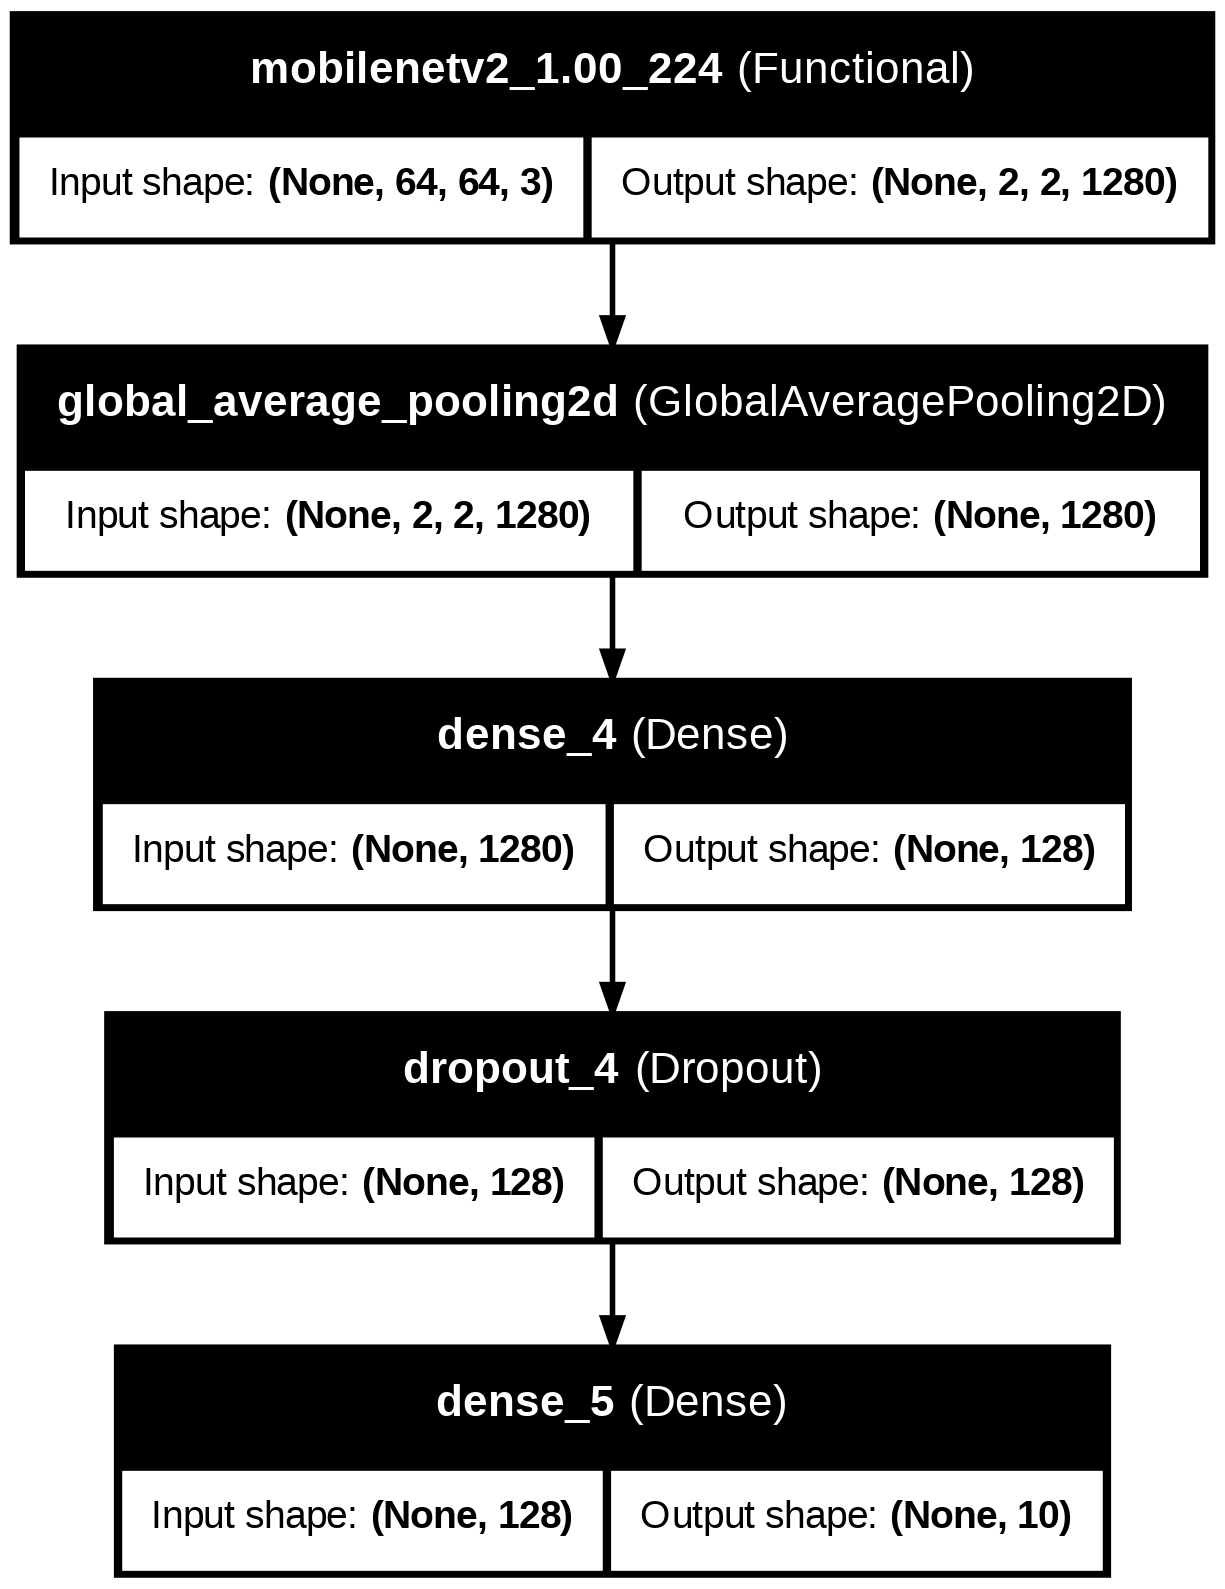

In [ ]:
# Save and visualize the model architecture
plot_model(model_five,
           to_file = "/content/drive/MyDrive/MUSA-650/model_five_architecture.png",
           show_shapes = True,
           show_layer_names = True)

In [ ]:
# Train Model Five
model_five_history = model_five.fit(X_train, y_train_categorical,
                                    validation_data = (X_test, y_test_categorical),
                                    epochs = epochs,
                                    batch_size = batch_size,
                                    verbose = 1)

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.6371 - loss: 1.1145 - val_accuracy: 0.8149 - val_loss: 0.5488
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7881 - loss: 0.6245 - val_accuracy: 0.8200 - val_loss: 0.5239
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8180 - loss: 0.5367 - val_accuracy: 0.8294 - val_loss: 0.4993
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8273 - loss: 0.5037 - val_accuracy: 0.8388 - val_loss: 0.4814
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8358 - loss: 0.4755 - val_accuracy: 0.8379 - val_loss: 0.4861
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8490 - loss: 0.4384 - val_accuracy: 0.8271 - val_loss: 0.5237
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8537 - loss: 0.4136 - val_accuracy: 0.8418 - val_loss: 0.4731
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8610 -

In [ ]:
# Evaluate Model Four on test data
model_five_test_loss, model_five_test_accuracy = model_five.evaluate(X_test, y_test_categorical, verbose = 0)

print(f"Test loss: {model_five_test_loss:.4f}.")
print(f"Test Accuracy: {model_five_test_accuracy * 100:.4f}%.")

Test loss: 0.4983.
Test Accuracy: 84.1389%.


Model 5 by far is the best model in terms of both test loss (0.4983) and accuracy (84.1389%) among all models trained.

As argued, pre-trained models are generally better than models we trained on our own owing to the access of much more resources.
As such, there is a potential to improve accuracy using pre-trained models as a base model, which is reflected here.

In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_five_history.json", "w") as f:
    json.dump(model_five_history.history, f)

model_five.save("/content/drive/MyDrive/MUSA-650/model_five.keras")

In [ ]:
# Get predictions from Model Five
predictions = model_five.predict(X_test)
predicted_labels = np.argmax(predictions, axis = 1)
true_labels = np.argmax(y_test_categorical, axis = 1)

# Identify misclassified examples
misclassified_indices = np.where(predicted_labels != true_labels)[0]

# Count errors per class
from collections import Counter

true_label_errors = true_labels[misclassified_indices]
error_counts = Counter(true_label_errors)

# Find the two classes with the highest errors
most_common_errors = error_counts.most_common(2)
print("Classes with highest labeling errors:", most_common_errors)

675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
Classes with highest labeling errors: [(np.int64(8), 592), (np.int64(2), 552)]


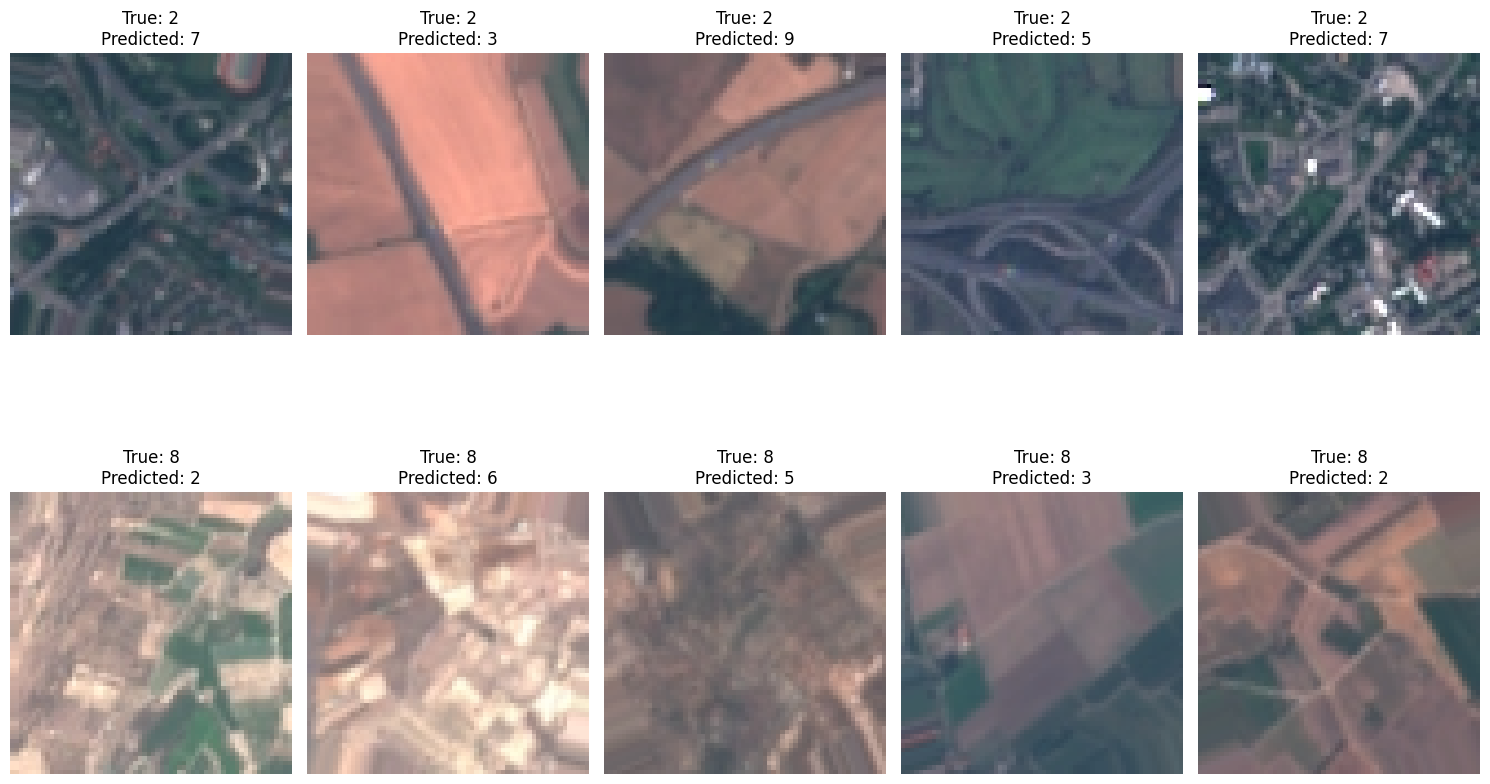

In [ ]:
# Classes with the highest labeling errors
error_classes = [cls[0] for cls in most_common_errors]  # Extract class IDs (e.g., 8 and 2)

# Filter misclassified indices for each specific class
filtered_indices_2 = [i for i in misclassified_indices if true_labels[i] == 2]  # True: Highway (2)
filtered_indices_8 = [i for i in misclassified_indices if true_labels[i] == 8]  # True: Permanent Crop (8)

# Number of examples to show per class
num_examples = 5

# Create a figure to display images horizontally in two rows
plt.figure(figsize=(15, 10))  # Adjust figure size

# Visualize misclassified examples for True: 2 (Highway)
for idx, i in enumerate(filtered_indices_2[:num_examples]):
    plt.subplot(2, num_examples, idx + 1)  # First row
    plt.imshow(X_test[i])  # Show the image
    plt.axis("off")  # Turn off axis for better visualization
    plt.title(f"True: {true_labels[i]}\nPredicted: {predicted_labels[i]}")

# Visualize misclassified examples for True: 8 (Permanent Crop)
for idx, i in enumerate(filtered_indices_8[:num_examples]):
    plt.subplot(2, num_examples, num_examples + idx + 1)  # Second row
    plt.imshow(X_test[i])  # Show the image
    plt.axis("off")  # Turn off axis for better visualization
    plt.title(f"True: {true_labels[i]}\nPredicted: {predicted_labels[i]}")

plt.tight_layout()
plt.show()

**<u>Discussion:</u>**
Recall that:
- Forest -> 0
- River -> 1
- Highway -> 2
- AnnualCrop -> 3
- SeaLake -> 4
- HerbaceousVegetation -> 5
- Industrial -> 6
- Residential -> 7
- PermanentCrop -> 8
- Pasture -> 9

Since highways are narrow roads running across different land covers and they occupy relatively few pixels compared to other land cover types such as residential, annual crop, etc., it is understandable that highways are frequently mis-classified based on areas surrounding them.

Permanent crop may share similar features with other land cover types such as herbaceous vegetation or annual crop.
If there are significant patterns present, it may also be confused with land cover types such as highways or industrial.

### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model’s performance? Explain the role of additional spectral information in enhancing land cover classification.

Loading in the multispectral images with four bands (RGB + NIR) takes 40 minutes.

In [ ]:
# Set the dataset path
dataset_path = "/content/drive/MyDrive/eurosat_ms/EuroSAT_MS"

# Initialize lists for storing images and labels
images = []
labels = []

# Iterate through each class directory
for label, class_name in enumerate(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, class_name)
    for image_file in os.listdir(class_dir):
        # Load the image using Rasterio
        image_path = os.path.join(class_dir, image_file)
        try:
            with rasterio.open(image_path) as src:
                # Extract specific bands (e.g., Red: Band 4, Green: Band 3, Blue: Band 2, NIR: Band 8)
                red = src.read(4)   # Band 4: Red
                green = src.read(3) # Band 3: Green
                blue = src.read(2)  # Band 2: Blue
                nir = src.read(8)   # Band 8: Near Infrared

                # Stack selected bands into a single array (shape: [height, width, 4])
                img_array = np.stack([red, green, blue, nir], axis=-1)

                # Normalize pixel values to [0, 1]
                img_array = img_array / np.iinfo(img_array.dtype).max

                # Resize to uniform size (64x64)
                img_resized = np.array(Image.fromarray((img_array * 255).astype(np.uint8)).resize((64, 64)))

                # Append the resized image and label
                images.append(img_resized)  # Shape: (64, 64, 4)
                labels.append(label)       # Numeric label for the class

        except Exception as e:
            print(f"Error processing file {image_path}: {e}")

# Convert lists to NumPy arrays
X_ms = np.array(images)  # Shape: (n_samples, 64, 64, 4)
y_ms = np.array(labels)  # Shape: (n_samples,)
print(f"Data shape: {X_ms.shape}, Labels shape: {y_ms.shape}")

Data shape: (27000, 64, 64, 4), Labels shape: (27000,)


In [ ]:
# Save combined data and labels using Pickle
with open("/content/drive/MyDrive/MUSA-650/A4_dataset_ms.pkl", "wb") as f:
    pickle.dump((X_ms, y_ms), f)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
# Load the saved data and labels using Pickle
with open("/content/drive/MyDrive/MUSA-650/A4_dataset_ms.pkl", "rb") as f:
    X_ms, y_ms = pickle.load(f)

print(f"Loaded dataset shapes: {X_ms.shape}, {y_ms.shape}")

Loaded dataset shapes: (27000, 64, 64, 4), (27000,)


In [ ]:
# Initialize ImageDataGenerator with rotation augmentation only
datagen = ImageDataGenerator(
    rotation_range = 30  # Random rotation up to 30 degrees
)

# Initialize lists for augmented images and labels
augmented_images = []
augmented_labels = []

# Apply rotation augmentation to each image in X_ms
for i in range(len(X_ms)):
    img = X_ms[i]  # Get the multispectral image (shape: 64x64x4)
    label = y_ms[i]  # Get the corresponding label

    # Reshape image for ImageDataGenerator (add batch dimension)
    img = img.reshape((1,) + img.shape)  # Shape: (1, 64, 64, 4)

    # Generate one augmented image per original image
    for batch in datagen.flow(img, batch_size = 1):
        augmented_images.append(batch[0])   # Append augmented image (no flattening)
        augmented_labels.append(label)      # Append corresponding label
        break  # Generate only one augmented image per original image

# Convert augmented data to NumPy arrays
X_ms_augmented = np.array(augmented_images)  # Shape: (n_samples_augmented, 64, 64, 4)
y_ms_augmented = np.array(augmented_labels)  # Shape: (n_samples_augmented,)

print(f"Augmented data shape: {X_ms_augmented.shape}, Augmented labels shape: {y_ms_augmented.shape}")

Augmented data shape: (27000, 64, 64, 4), Augmented labels shape: (27000,)


In [ ]:
# Combine original data (X, y) with augmented data (X_augmented, y_augmented)
X_ms_combined = np.vstack((X_ms, X_ms_augmented))
y_ms_combined = np.hstack((y_ms, y_ms_augmented))

print(f"Total dataset size after augmentation: {X_ms_combined.shape}, Labels shape: {y_ms_combined.shape}")

Total dataset size after augmentation: (54000, 64, 64, 4), Labels shape: (54000,)


In [ ]:
# Save combined data and labels using Pickle
with open("/content/drive/MyDrive/MUSA-650/A4_dataset_ms_combined.pkl", "wb") as f:
    pickle.dump((X_ms_combined, y_ms_combined), f)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
# Load the saved data and labels using Pickle
with open("/content/drive/MyDrive/MUSA-650/A4_dataset_ms_combined.pkl", "rb") as f:
    X_ms_combined, y_ms_combined = pickle.load(f)

print(f"Loaded dataset shapes: {X_ms_combined.shape}, {y_ms_combined.shape}")

Loaded dataset shapes: (54000, 64, 64, 4), (54000,)


In [ ]:
# Split combined data into training (60%) and testing (40%) sets
X_ms_train, X_ms_test, y_ms_train, y_ms_test = train_test_split(
    X_ms_combined, y_ms_combined,
    test_size = 0.4,
    random_state = 42,
    stratify = y_ms_combined  # Ensure class proportions are preserved
)

print(f"Training data shape: {X_ms_train.shape}, Testing data shape: {X_ms_test.shape}")

Training data shape: (32400, 64, 64, 4), Testing data shape: (21600, 64, 64, 4)


In [ ]:
# Normalize grayscale images to [0, 1]
X_ms_train = X_ms_train / 255.0
X_ms_test = X_ms_test / 255.0

# One-hot encode the labels
num_classes = len(np.unique(y_ms_train))  # Number of land cover categories
y_ms_train_categorical = to_categorical(y_ms_train, num_classes = num_classes)
y_ms_test_categorical = to_categorical(y_ms_test, num_classes = num_classes)

print(f"X_ms_train shape: {X_ms_train.shape}, y_ms_train_categorical shape: {y_ms_train_categorical.shape}")
print(f"X_ms_test shape: {X_ms_test.shape}, y_ms_test_categorical shape: {y_ms_test_categorical.shape}")

X_ms_train shape: (32400, 64, 64, 4), y_ms_train_categorical shape: (32400, 10)
X_ms_test shape: (21600, 64, 64, 4), y_ms_test_categorical shape: (21600, 10)


In [ ]:
# Define input shape for RGB + NIR (4 channels)
input_shape = (64, 64, 4)

# Define the input layer for multispectral data
input_layer = Input(shape = input_shape)

# Add a Conv2D layer to map 4 channels to 3 channels (to mimic original MobileNetV2 input)
conv_layer = Conv2D(3, (1, 1), activation = "relu")(input_layer)  # Reduce channels from 4 to 3

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(weights = "imagenet", include_top = False, input_shape = (64, 64, 3))

# Freeze the base model layers to retain pre-trained features
base_model.trainable = False

# Pass the output of the Conv2D layer into the base model
x = base_model(conv_layer)

# Add global average pooling and fully connected layers to mimic original Model Five
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation = "relu")(x)  # Fully connected layer with ReLU activation
x = Dropout(0.5)(x)                   # Dropout for regularization
output_layer = Dense(num_classes, activation = "softmax")(x)  # Output layer for classification

# Define the final model
model_multispectral = Model(inputs = input_layer, outputs = output_layer)

# Compile the model
model_multispectral.compile(optimizer = "adam",
                            loss = "categorical_crossentropy",
                            metrics = ["accuracy"])

# Print model summary
model_multispectral.summary()

<ipython-input-6-be9afc9cb0e2>:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights = "imagenet", include_top = False, input_shape = (64, 64, 3))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 3)           │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 2, 2, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,257 (9.24 MB)

 Trainable params: 165,273 (645.60 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
epochs = 10
batch_size = 32

model_multispectral_history = model_multispectral.fit(
    X_ms_train,
    y_ms_train_categorical,
    validation_data = (X_ms_test, y_ms_test_categorical),
    epochs = epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.3752 - loss: 1.7527 - val_accuracy: 0.5518 - val_loss: 1.2491
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5048 - loss: 1.3577 - val_accuracy: 0.5834 - val_loss: 1.1444
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.5338 - loss: 1.2754 - val_accuracy: 0.6009 - val_loss: 1.1406
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5502 - loss: 1.2365 - val_accuracy: 0.5836 - val_loss: 1.1152
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.5535 - loss: 1.2191 - val_accuracy: 0.6100 - val_loss: 1.0668
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5650 - loss: 1.1889 - val_accuracy: 0.6127 - val_loss: 1.0524
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.5712 - loss: 1.1725 - val_accuracy: 0.6207 - val_loss: 1.0524
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.5807 -

In [ ]:
# Evaluate Model Four on test data
model_multispectral_test_loss, model_multispectral_test_accuracy = model_multispectral.evaluate(X_ms_test, y_ms_test_categorical, verbose = 0)

print(f"Test loss: {model_multispectral_test_loss:.4f}.")
print(f"Test Accuracy: {model_multispectral_test_accuracy * 100:.4f}%.")

Test loss: 1.0142.
Test Accuracy: 62.4583%.


In [ ]:
# Save history as a JSON file
with open("/content/drive/MyDrive/MUSA-650/model_multispectral_history.json", "w") as f:
    json.dump(model_multispectral_history.history, f)

model_multispectral.save("/content/drive/MyDrive/MUSA-650/model_multispectral.keras")

**<u>Impact on model performance:</u>**
For this question, I only added the NIR band.
However, adding this channel negatively impacted the model performance, reducing the test accuracy from 84.1389% to 62.4583%.
- The base model for the transfer learning is MobileNetV2.
By default, MobileNetV2 handles 3-channel images (RGB), so the pre-trained weights may be sub-optimal in handling spectral information inherited in other spectral bands such as NIR.
- The NIR band reflects vegetation, but the EuroSAT dataset's land cover classes may not all benefit from this extra piece of information uniformly.

**<u>Role of additioinal spectral information in enhancing land cover classification:</u>**
- Additional spectral information provides additional spectral signatures, which could improve the classification of visually similar classes on RGB chanels-only images.
- Additional spectral information allows for richer feature extractions, thus potentially enhancing the ability for properly-trained models to classify land covers.

## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? If you answered the bonus questions, how did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?

**<u>Takeaways from parameters tuning:</u>**
- Carefuly and proper hyperparameters tuning is paramount in model trainings, especially for deep learning models.
For instance, the percentages of dropout in each of the dropout layers could significantly impact model performance.
Using different number of epochs, batch sizes, learning rates, etc., could also impact model performances, although in this assignment, not every aspect is explored.

**<u>Increasing number of epochs:</u>**
- The most straightforward observation is that it requires more time to train the models, but this is nothing surprising; the more we train, the more time it takes.
- Increasing the number of epochs in general could improve model performance, but it also depends on whether we start with a "good-enough" model.
For instance, doubling the number of epochs from 10 to 20 for Model 1 does not result in significant improvements in model performance.
This is likely due to the fact that Model 1 is way too simplistic for a complex task like land cover classification.
- Since I start with a small number of epochs, even after doubling it, the number of epochs remain pretty small, so it did not pose significant challenges.

**<u>Impacts of using dropout:</u>**
- Dropout layers help prevent overfitting and improve the ability of the model to generalize.
- Over-dropout may result in underfitting, so proper tuning is required.

**<u>Ensemble method:</u>**
As mentioned in previous section, the ensemble method bears the potential to improve model accuracy compared to individual models.
- The ensemble model's test accuracy is higher than that of Models 1 and 2, but lower than that of Model 3.
- Ensembling combines the strengths of various models, while mitigating weaknesses of individual models by compensating with other included models.
- Ensembling can reduce variance by averaging out errors across models, leading more stable and robust predictions.
Also, aggregating predictions can help lessen the sensitivity of the data to noise and reduce the risk of overfitting.

**<u>Challenges/Limitations:</u>**
- Computational resources and time pose major challenges to me.
While I can train simpler models, such as traditional machine learning models (SVM and random forest), and deep learning models 1 - 3, with CPU resources, I have to switch to GPU resources when training CNNs and transfer learning models.
I also have to get rid of unused datasets before running those models; otherwise I often risk exceeding the RAM limit.
- Following the above point, memory is another major limitation.
We start with 27,000 images (RGB or multispectral), which already takes up a substantial amount of memories on their own.
As such, we cannot perform too many data augmentations to expand the samples, otherwise we will run out of memories.
The issue is particularly salient with multispectral images, in which they are very memory-intensive.
- In the future, if deep learning models are needed, I would try to leverge the university's computational resources.
For instance, instead of training models locally, I would try to submit jobs to the university's computing cluster to utilize more and more powerful computational resources.

**<u>Application to other deep learning problems:</u>**
- Let's say I have another deep learning problem related to images.
Based on what I have learnt in this assignment, I understand the importance of data preprocessing, including data augmentation to expand the sample, normalization to reduce training time, improve convergence, and maximize generalizability, careful model and hyperparameter tuning to maximize model performance.
- Even when I am not working with images, the experience I have from this assignment provides me with better insights on how to properly handle data, as well as determining a suitable model architecture and tune hyperparameters more carefully, given that I witness first-hand the impact of, e.g., dropout.

For this assignment, I consulted Perplexity, as well as in-class notebooks such as "DLBasics_SimpleCNN.ipynb", "DLBasics_KerasDataAugmentation.ipynb", and "DLBasics_KerasDataAugmentation_Application.ipynb".